In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

In [126]:
df = pd.read_csv(r"c:\Users\davie\OneDrive\Desktop\Year 4 University\Dissertation\daily_masses_cdse\Villarrica_2018-06-01_2026-03-01_SO2_time_seriesnanmean.csv")
df['date'] = pd.to_datetime(df['date'])
 

In [127]:
# Convert to datetime, coercing invalid values to NaT
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows where the date is invalid (NaT)
df = df.dropna(subset=['date'])

# Now sort by date
df = df.sort_values('date')

In [ ]:
# so2_cols = ['volcano'] + [f'clear_{i}' for i in range(1, 9)]
# df[so2_cols] = df[so2_cols].replace(0, np.nan)
# df[so2_cols] = df[so2_cols].interpolate()# 

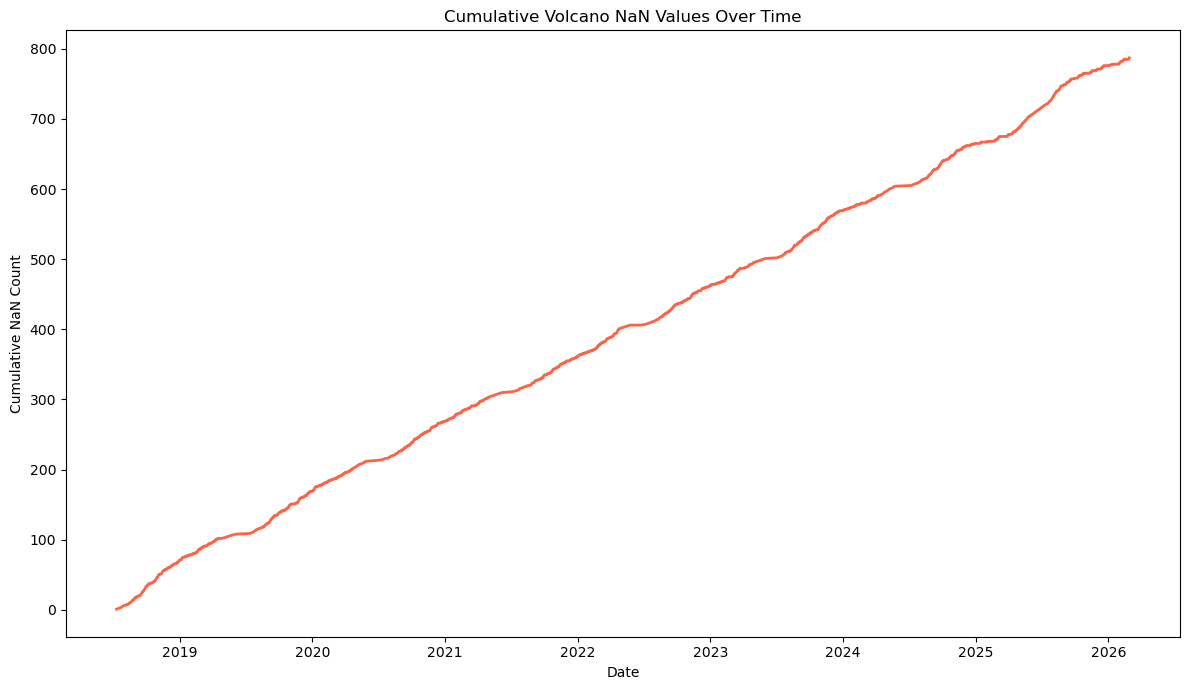

In [128]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# --- Replace 0s with NaN and track cumulative NaNs ---
df['volcano'] = df['volcano'].replace(0, np.nan)
df['cumulative_nans'] = df['volcano'].isna().astype(int).cumsum()

# --- Plot ---
plt.figure(figsize=(12, 7))
plt.plot(df['date'], df['cumulative_nans'], lw=2, color='tomato')

plt.xlabel('Date')
plt.ylabel('Cumulative NaN Count')
plt.title('Cumulative Volcano NaN Values Over Time')

plt.tight_layout()
plt.show()

In [94]:
import pandas as pd
import numpy as np

df['volcano'] = df['volcano'].replace(0, np.nan)

nan_count = df['volcano'].isna().sum()
nan_pct = (nan_count / len(df)) * 100

print(f"NaN count: {nan_count}")
print(f"NaN percentage: {nan_pct:.2f}%")

NaN count: 6
NaN percentage: 0.28%


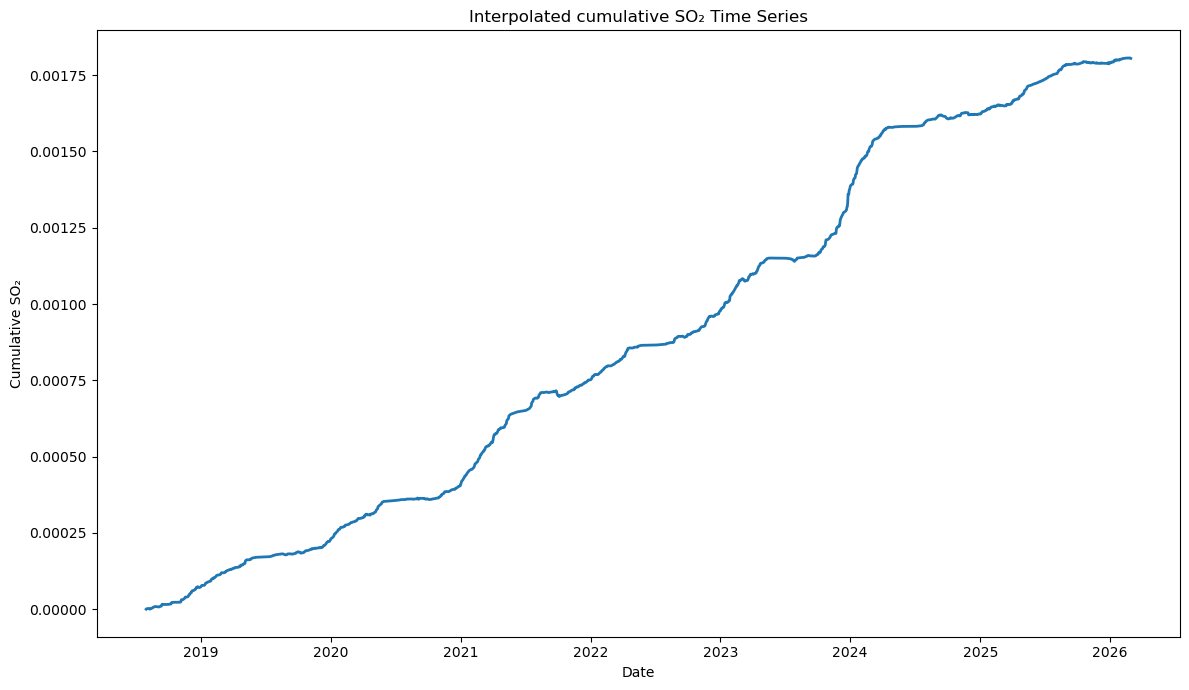

In [95]:
# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Replace zeros with NaN and interpolate
df['volcano'] = df['volcano'].replace(0, np.nan)
df['volcano'] = df['volcano'].interpolate()

# --- Cumulative sum ---
df['cumulative_so2'] = df['volcano'].cumsum()

# --- Plot cumulative SO₂ ---
plt.figure(figsize=(12,7))
plt.plot(df['date'], df['cumulative_so2'], lw=2)

plt.xlabel('Date')
plt.ylabel('Cumulative SO₂')
plt.title('Interpolated cumulative SO₂ Time Series')

plt.tight_layout()
plt.show()

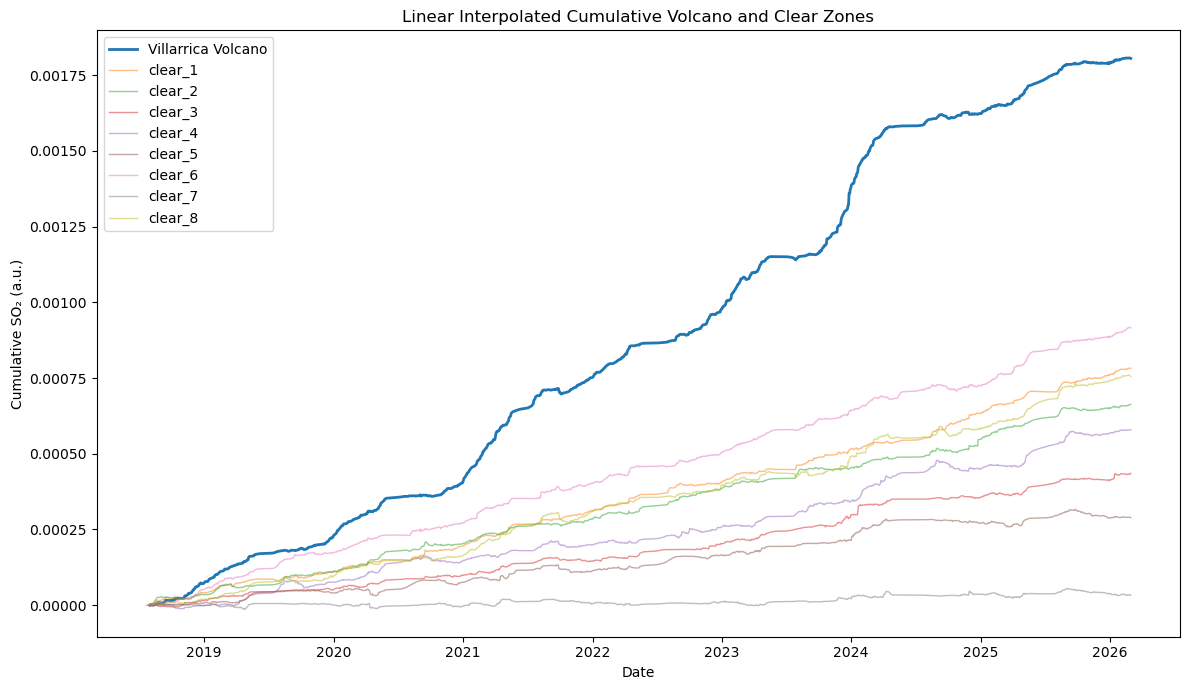

In [97]:
# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Replace zeros with NaN and interpolate all columns
df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

# --- Calculate cumulative sum ---
df['cumulative_volcano'] = df['volcano'].cumsum()

clear_cols = [f'clear_{i}' for i in range(1, 9)]
for col in clear_cols:
    df[f'cumulative_{col}'] = df[col].cumsum()

# --- Plot ---
plt.figure(figsize=(12,7))

# Volcano line
plt.plot(df['date'], df['cumulative_volcano'], lw=2, label='Villarrica Volcano')

# Clear zones
for col in clear_cols:
    plt.plot(df['date'], df[f'cumulative_{col}'], lw=1, alpha=0.5, label=col)

plt.xlabel('Date')
plt.ylabel('Cumulative SO₂ (a.u.)')
plt.title('Linear Interpolated Cumulative Volcano and Clear Zones')
plt.legend()

plt.tight_layout()
plt.savefig("figure02.png", dpi=800, bbox_inches='tight')
plt.show()

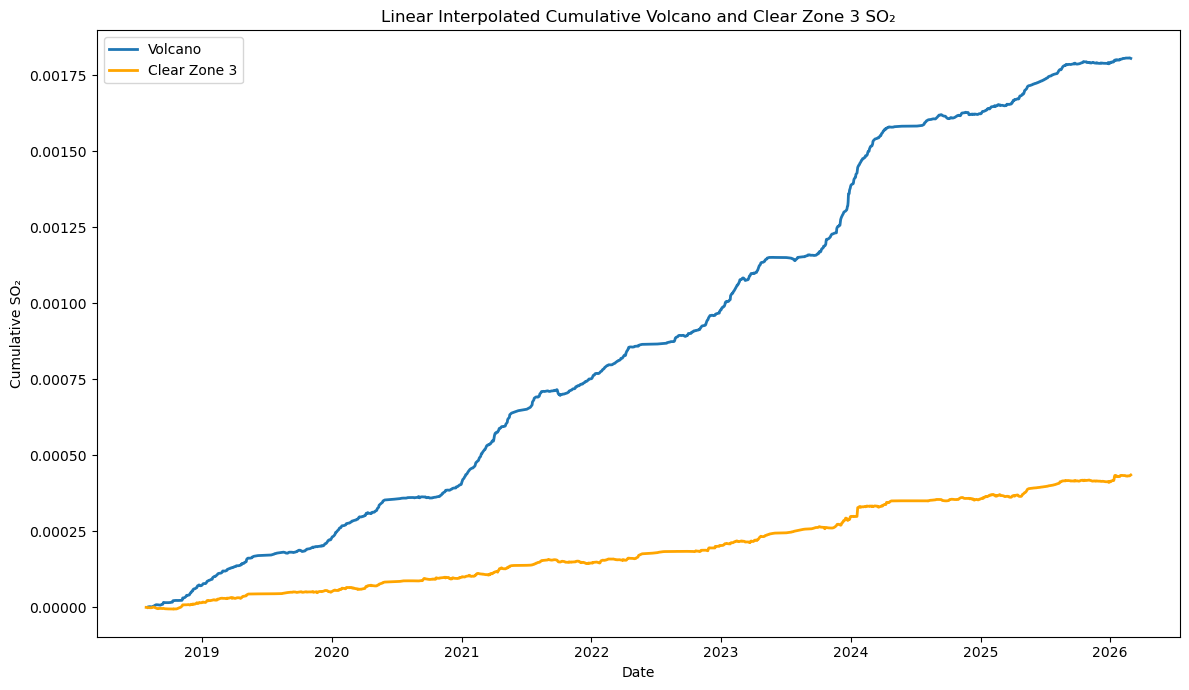

In [98]:
# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Replace zeros with NaN and interpolate all columns
df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

# --- Compute mean of clear zones ---
# clear_cols = [f'clear_{i}' for i in range(1, 9)]
# df['clear_mean'] = df[clear_cols].mean(axis=1)

# --- Compute cumulative sums ---
df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()

# --- Plot ---
plt.figure(figsize=(12,7))

# Volcano cumulative
plt.plot(df['date'], df['cumulative_volcano'], lw=2, label='Volcano')

# Mean clear-zone cumulative
plt.plot(df['date'], df['cumulative_clear_3'], color='orange', lw=2, label='Clear Zone 3')

plt.xlabel('Date')
plt.ylabel('Cumulative SO₂')
plt.title('Linear Interpolated Cumulative Volcano and Clear Zone 3 SO₂')
plt.legend()

plt.tight_layout()
plt.show()

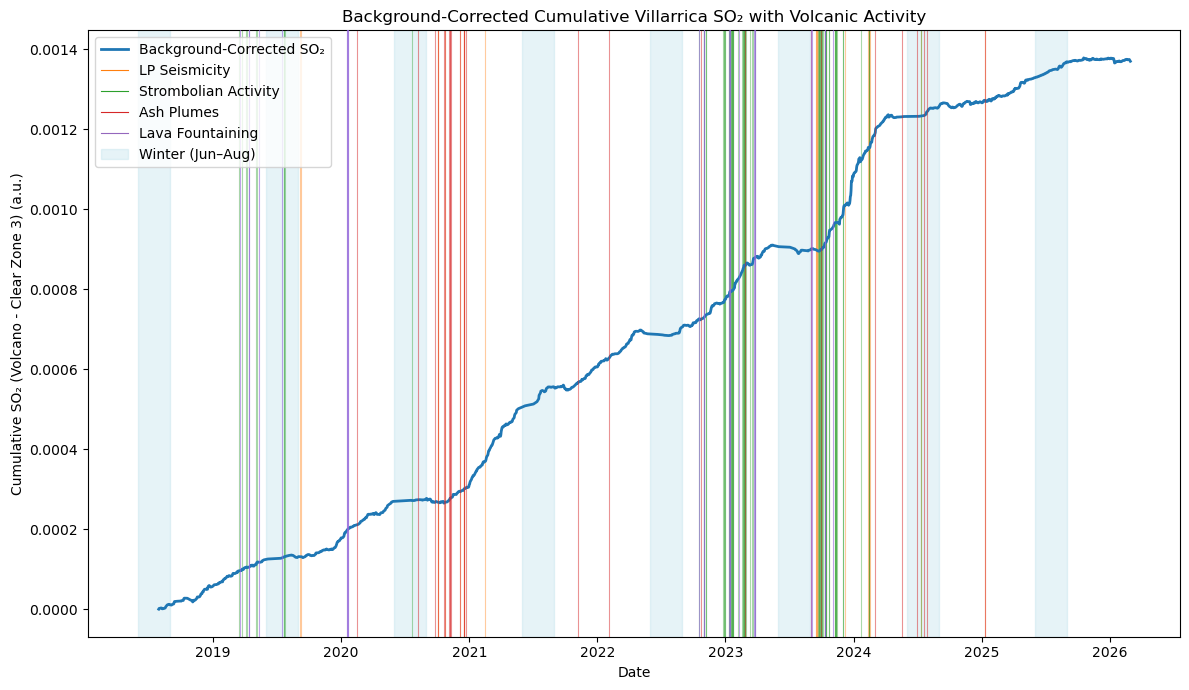

In [99]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Replace zeros with NaN and interpolate
df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

# --- Compute cumulative sums ---
df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()

# --- Compute background-corrected cumulative SO2 ---
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

# =============================================================================
# --- VOLCANIC ACTIVITY DATES ---
# =============================================================================
strombolian_dates = [
    '17/03/2019','24/03/2019','07/04/2019','08/04/2019','05/05/2019','06/05/2019',
    '23/07/2019','24/07/2019','25/07/2019','23/07/2020','18/10/2022','31/10/2022',
    '01/11/2022','02/11/2022','06/11/2022','07/11/2022','24/12/2022','28/12/2022',
    '29/12/2022','30/12/2022','31/12/2022','11/01/2023','12/01/2023','14/01/2023',
    '15/01/2023','17/01/2023','18/01/2023','19/01/2023','20/01/2023','21/01/2023',
    '22/01/2023','23/01/2023','24/01/2023','06/02/2023','17/02/2023','20/02/2023',
    '21/02/2023','22/02/2023','23/02/2023','24/02/2023','25/02/2023','26/02/2023',
    '27/02/2023','28/02/2023','13/03/2023','18/03/2023','21/03/2023','26/03/2023',
    '23/09/2023','24/09/2023','25/09/2023','26/09/2023','27/09/2023','28/09/2023',
    '29/09/2023','30/09/2023','01/10/2023','02/10/2023','03/10/2023','06/10/2023',
    '11/10/2023','12/10/2023','13/10/2023','14/10/2023','15/10/2023','16/10/2023',
    '22/10/2023','23/10/2023','08/11/2023','09/11/2023','10/11/2023','11/11/2023',
    '12/11/2023','13/11/2023','14/11/2023','02/12/2023','03/12/2023','22/01/2024',
    '13/02/2024','14/02/2024','10/07/2024'
]

lava_fountain_dates = [
    '20/03/2019','14/04/2019','15/04/2019','14/05/2019','16/07/2019','18/01/2020',
    '19/01/2020','20/01/2020','22/01/2020','18/10/2022','01/11/2022','02/11/2022',
    '11/01/2023','14/01/2023','15/01/2023','09/02/2023','24/03/2023','25/03/2023',
    '26/03/2023','03/09/2023','04/09/2023','11/10/2023','12/10/2023','03/11/2023'
]

lp_dates = [
    '08/09/2019','09/09/2019','04/10/2020','05/10/2020','23/10/2020',
    '05/12/2020','16/12/2020','17/12/2020','16/02/2021','15/09/2023',
    '16/09/2023','18/09/2023','20/09/2023','21/09/2023','09/12/2023',
    '12/02/2024','13/02/2024','14/02/2024','15/02/2024','17/02/2024',
    '10/07/2024','11/01/2025'
]

ash_dates = [
    '07/08/2020','25/09/2020','05/10/2020','20/10/2020','23/10/2020',
    '05/11/2020','06/11/2020','08/11/2020','10/11/2020','05/12/2020',
    '16/12/2020','17/12/2020','22/12/2020','16/02/2020','06/11/2021',
    '02/02/2022','23/10/2022','27/02/2023','02/09/2023','30/09/2023',
    '03/03/2024','18/05/2024','29/06/2024','21/07/2024','29/07/2024',
    '11/01/2025'
]

# --- Convert dates BEFORE plotting ---
strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

# --- Create figure and axis ONCE, use ax1 consistently ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- Plot background-corrected cumulative signal ---
ax1.plot(df['date'], df['cumulative_true_volcano'], lw=2, color='#1f77b4',
         label='Background-Corrected Volcano')

years = range(2018, 2026)
winter_labeled = False
for year in years:
    label = 'Winter (Jun–Aug)' if not winter_labeled else None
    ax1.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
                color='lightblue', alpha=0.3, label=label, zorder=0)
    winter_labeled = True

# --- Vertical event lines ---
for date in lp_dt:
    ax1.axvline(date, color='#ff7f0e', alpha=0.4, lw=0.8, zorder=0)
for date in strombolian_dt:
    ax1.axvline(date, color='#2ca02c',      alpha=0.4, lw=0.8, zorder=1)
for date in ash_dt:
    ax1.axvline(date, color='#d62728', alpha=0.5, lw=0.8, zorder=2)
for date in lava_fountain_dt:
    ax1.axvline(date, color='#9467db',         alpha=0.6, lw=0.8, zorder=3)

legend_elements = [
    Line2D([0], [0], color='#1f77b4',   lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color='#ff7f0e',  lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color='#2ca02c',      lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color='#d62728', lw=0.8, label='Ash Plumes'),
    Line2D([0], [0], color='#9467bd',         lw=0.8, label='Lava Fountaining'),
    mpatches.Patch(color='lightblue', alpha=0.3, label='Winter (Jun–Aug)'),  # patch for shaded region
]
ax1.legend(handles=legend_elements, loc='upper left')

ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative SO₂ (Volcano - Clear Zone 3) (a.u.)')
ax1.set_title('Background-Corrected Cumulative Villarrica SO₂ with Volcanic Activity')

plt.tight_layout()
plt.show()

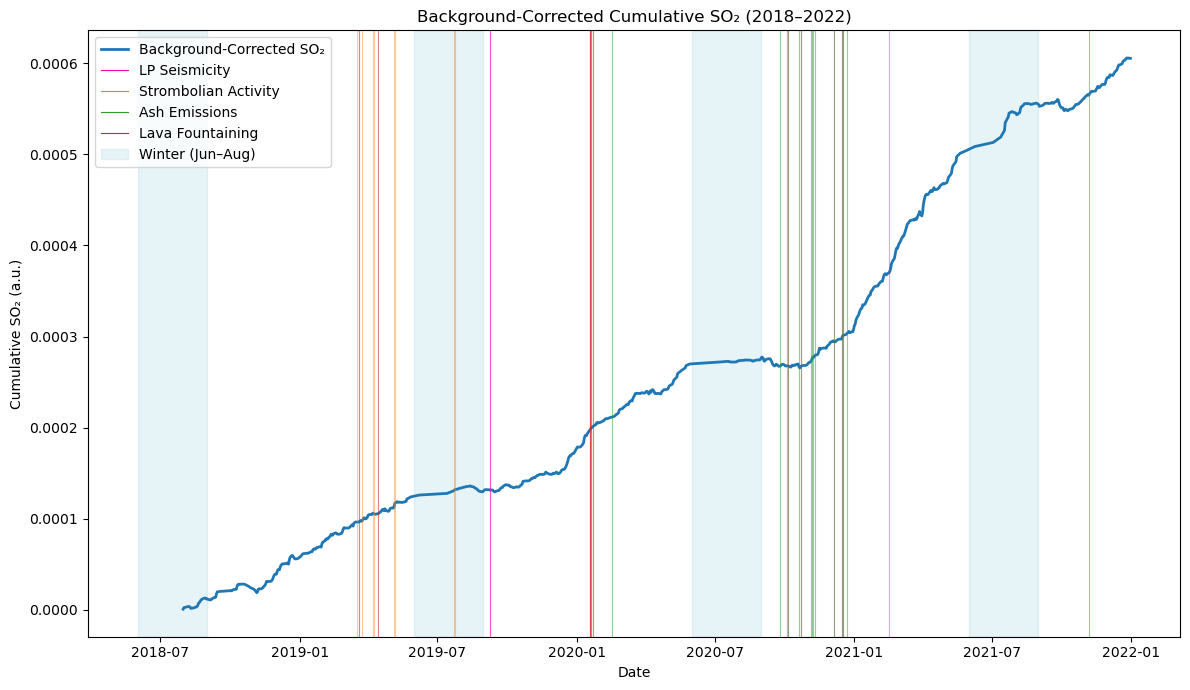

In [100]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Replace zeros with NaN and interpolate
df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

# --- Compute cumulative sums ---
df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()

# --- Compute background-corrected cumulative SO2 ---
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

# --- Split into two time windows ---
df_1 = df[(df['date'] >= '2018-01-01') & (df['date'] < '2022-01-01')]
df_2 = df[(df['date'] >= '2022-01-01') & (df['date'] <= '2026-01-01')]

# --- VOLCANIC ACTIVITY DATES ---
strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

# --- Colour-blind-safe palette (tab10) ---
SO2_col   = '#1f77b4'
LP_col    = '#FF00AA'
STROM_col = '#ff7f0e'
ASH_col   = '#2ca02c'
FNT_col   = '#d62728'

legend_elements = [
    Line2D([0], [0], color=SO2_col,   lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=LP_col,    lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col, lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,   lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,   lw=0.8, label='Lava Fountaining'),
    mpatches.Patch(color='lightblue', alpha=0.3, label='Winter (Jun–Aug)')
]
fig, ax1 = plt.subplots(figsize=(12, 7))

# SO₂ curve
ax1.plot(df_1['date'], df_1['cumulative_true_volcano'], lw=2, color=SO2_col)

# Winter shading
for year in range(2018, 2022):
    ax1.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
                color='lightblue', alpha=0.3, zorder=0)

# Event lines
for d in lp_dt:
    if d in df_1['date'].values:
        ax1.axvline(d, color=LP_col, alpha=0.4, lw=0.8)
for d in strombolian_dt:
    if d in df_1['date'].values:
        ax1.axvline(d, color=STROM_col, alpha=0.4, lw=0.8)
for d in ash_dt:
    if d in df_1['date'].values:
        ax1.axvline(d, color=ASH_col, alpha=0.5, lw=0.8)
for d in lava_fountain_dt:
    if d in df_1['date'].values:
        ax1.axvline(d, color=FNT_col, alpha=0.6, lw=0.8)

ax1.set_title('Background-Corrected Cumulative SO₂ (2018–2022)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative SO₂ (a.u.)')
ax1.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()


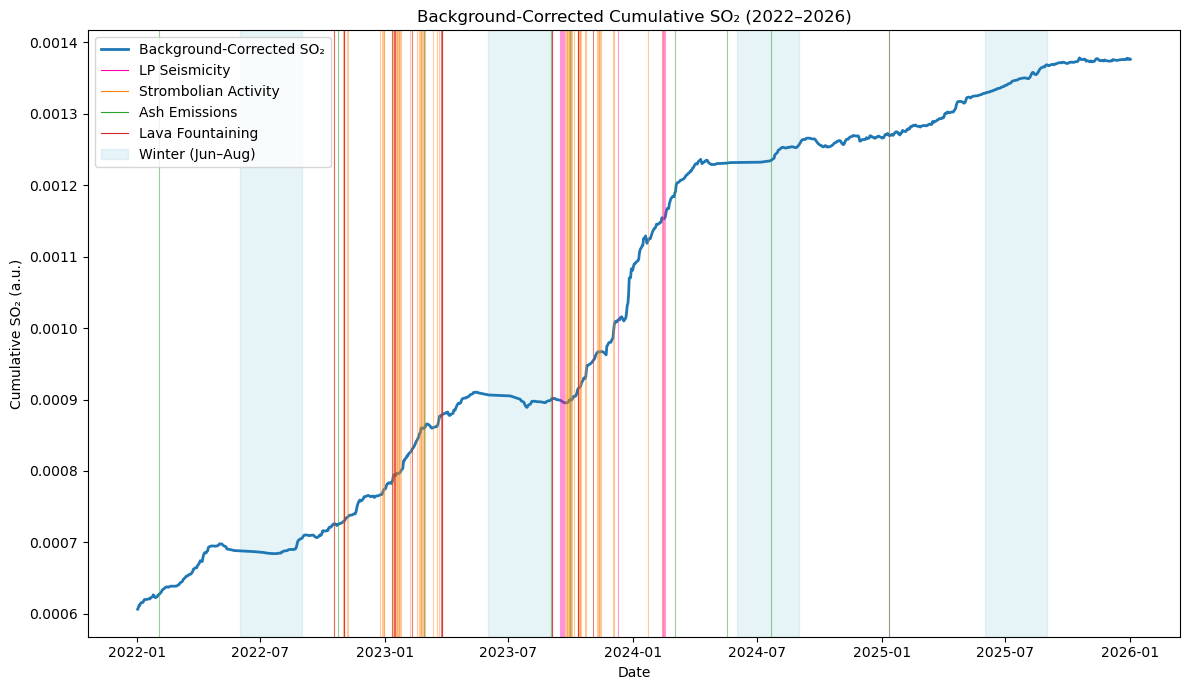

In [101]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Replace zeros with NaN and interpolate
df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

# --- Compute cumulative sums ---
df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()

# --- Compute background-corrected cumulative SO2 ---
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

# --- Split into two time windows ---
df_1 = df[(df['date'] >= '2018-01-01') & (df['date'] < '2022-01-01')]
df_2 = df[(df['date'] >= '2022-01-01') & (df['date'] <= '2026-01-01')]

# --- VOLCANIC ACTIVITY DATES ---
strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

# --- Colour-blind-safe palette (tab10) ---
SO2_col   = '#1f77b4'
LP_col    = '#FF00AA'
STROM_col = '#ff7f0e'
ASH_col   = '#2ca02c'
FNT_col   = '#d62728'

legend_elements = [
    Line2D([0], [0], color=SO2_col,   lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=LP_col,    lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col, lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,   lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,   lw=0.8, label='Lava Fountaining'),
    mpatches.Patch(color='lightblue', alpha=0.3, label='Winter (Jun–Aug)')
]

fig, ax1 = plt.subplots(figsize=(12, 7))

# SO₂ curve
ax1.plot(df_2['date'], df_2['cumulative_true_volcano'], lw=2, color=SO2_col)

# Winter shading
for year in range(2022, 2026):
    ax1.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
                color='lightblue', alpha=0.3, zorder=0)

# Event lines
for d in lp_dt:
    if d in df_2['date'].values:
        ax1.axvline(d, color=LP_col, alpha=0.4, lw=0.8)
for d in strombolian_dt:
    if d in df_2['date'].values:
        ax1.axvline(d, color=STROM_col, alpha=0.4, lw=0.8)
for d in ash_dt:
    if d in df_2['date'].values:
        ax1.axvline(d, color=ASH_col, alpha=0.5, lw=0.8)
for d in lava_fountain_dt:
    if d in df_2['date'].values:
        ax1.axvline(d, color=FNT_col, alpha=0.6, lw=0.8)

ax1.set_title('Background-Corrected Cumulative SO₂ (2022–2026)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative SO₂ (a.u.)')
ax1.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()


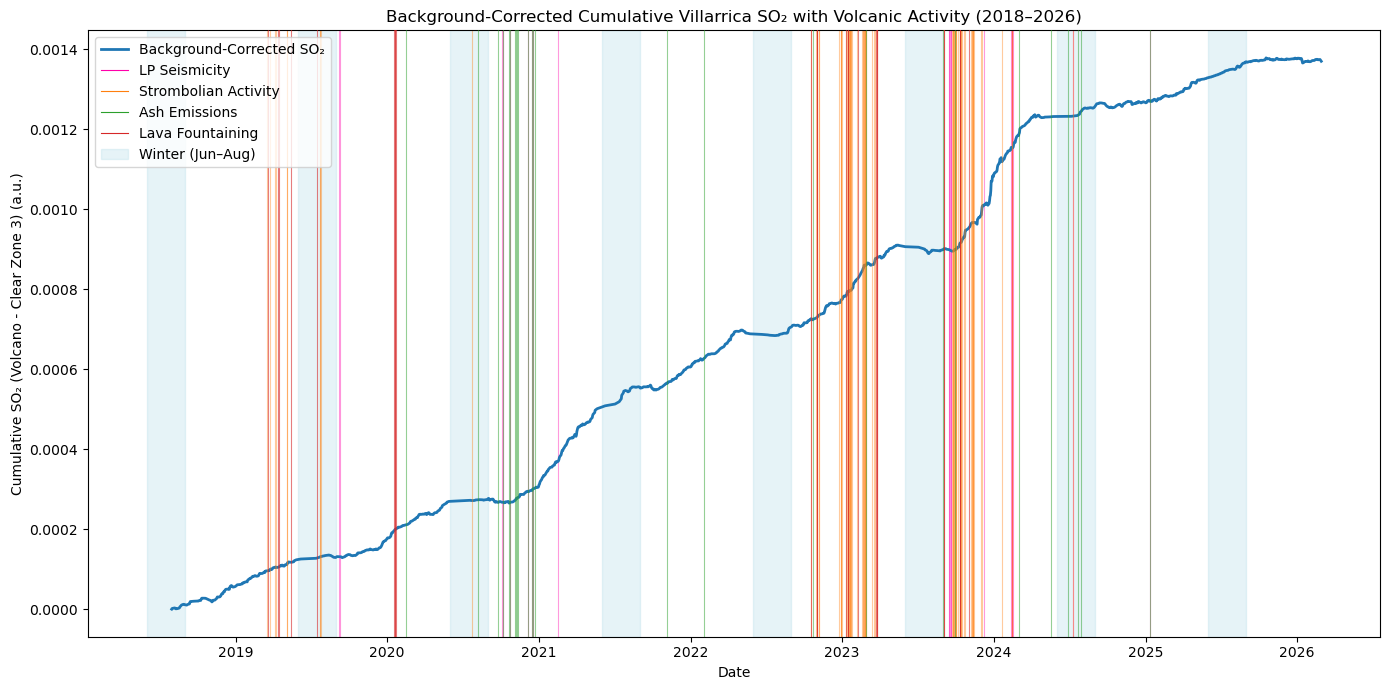

In [102]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Replace zeros with NaN and interpolate
df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

# --- Compute cumulative sums ---
df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()

# --- Compute background-corrected cumulative SO2 ---
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

# --- Convert event dates ---
strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

# --- Colour-blind-safe palette (tab10) ---
SO2_col   = '#1f77b4'
LP_col    = '#FF00AA'
STROM_col = '#ff7f0e'
ASH_col   = '#2ca02c'
FNT_col   = '#d62728'

# --- Create figure ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Plot background-corrected cumulative SO2 ---
ax1.plot(df['date'], df['cumulative_true_volcano'], lw=2, color=SO2_col,
         label='Background-Corrected SO₂')

# --- Winter shading for all years ---
for year in range(2018, 2026):
    ax1.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
                color='lightblue', alpha=0.3, zorder=0)

# --- Vertical event lines ---
for date in lp_dt:
    ax1.axvline(date, color=LP_col, alpha=0.4, lw=0.8, zorder=1)

for date in strombolian_dt:
    ax1.axvline(date, color=STROM_col, alpha=0.4, lw=0.8, zorder=2)

for date in ash_dt:
    ax1.axvline(date, color=ASH_col, alpha=0.5, lw=0.8, zorder=3)

for date in lava_fountain_dt:
    ax1.axvline(date, color=FNT_col, alpha=0.6, lw=0.8, zorder=4)

# --- Legend ---
legend_elements = [
    Line2D([0], [0], color=SO2_col,   lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=LP_col,    lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col, lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,   lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,   lw=0.8, label='Lava Fountaining'),
    mpatches.Patch(color='lightblue', alpha=0.3, label='Winter (Jun–Aug)')
]

ax1.legend(handles=legend_elements, loc='upper left')

# --- Labels and title ---
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative SO₂ (Volcano - Clear Zone 3) (a.u.)')
ax1.set_title('Background-Corrected Cumulative Villarrica SO₂ with Volcanic Activity (2018–2026)')

plt.tight_layout()
plt.show()


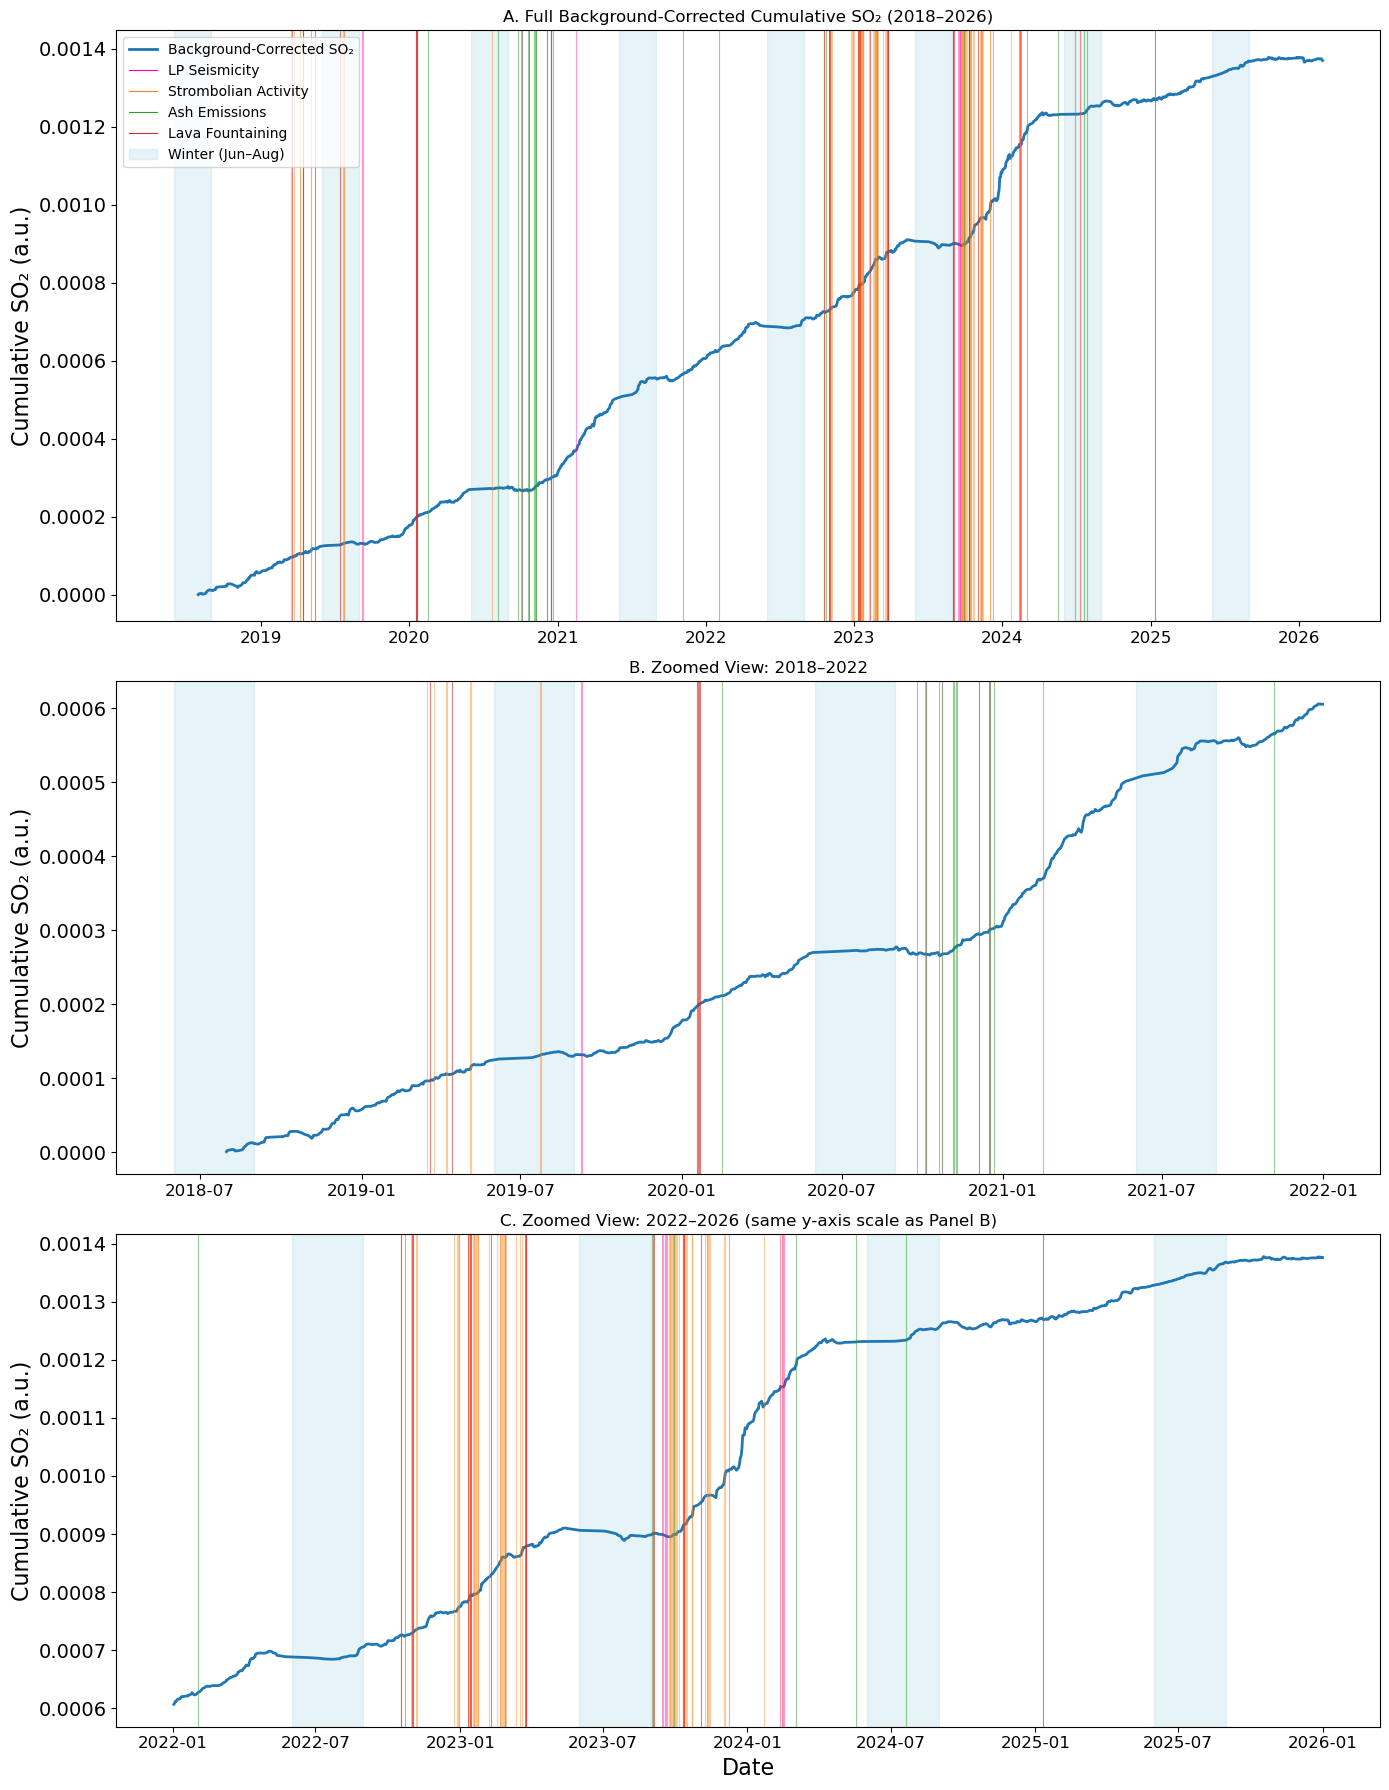

In [103]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

# --- Split datasets ---
df_1 = df[(df['date'] >= '2018-01-01') & (df['date'] < '2022-01-01')]
df_2 = df[(df['date'] >= '2022-01-01') & (df['date'] <= '2026-01-01')]

# --- Convert event dates ---
strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

# --- High‑impact vivid colours ---
SO2_col   = '#1f77b4'
LP_col    = '#FF00AA'
STROM_col = '#ff7f0e'
ASH_col   = '#2ca02c'
FNT_col   = '#d62728'

# --- Legend elements ---
legend_elements = [
    Line2D([0], [0], color=SO2_col,   lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=LP_col,    lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col, lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,   lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,   lw=0.8, label='Lava Fountaining'),
    mpatches.Patch(color='lightblue', alpha=0.3, label='Winter (Jun–Aug)')
]

# --- Create 3-panel figure ---
fig, axes = plt.subplots(3, 1, figsize=(14, 18), gridspec_kw={'height_ratios': [1.2, 1, 1]})

for ax in axes:
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=12)
    ax.yaxis.label.set_size(16)
    ax.xaxis.label.set_size(16)


# ============================================================
# PANEL A — FULL TIME SERIES (2018–2026)
# ============================================================
ax = axes[0]
ax.plot(df['date'], df['cumulative_true_volcano'], lw=2, color=SO2_col)

for year in range(2018, 2026):
    ax.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
               color='lightblue', alpha=0.3, zorder=0)

for d in lp_dt: ax.axvline(d, color=LP_col, alpha=0.4, lw=0.8)
for d in strombolian_dt: ax.axvline(d, color=STROM_col, alpha=0.4, lw=0.8)
for d in ash_dt: ax.axvline(d, color=ASH_col, alpha=0.5, lw=0.8)
for d in lava_fountain_dt: ax.axvline(d, color=FNT_col, alpha=0.6, lw=0.8)

ax.set_title("A. Full Background-Corrected Cumulative SO₂ (2018–2026)")
ax.set_ylabel("Cumulative SO₂ (a.u.)")
ax.legend(handles=legend_elements, loc='upper left')

# ============================================================
# PANEL B — ZOOM 2018–2022
# ============================================================
ax = axes[1]
ax.plot(df_1['date'], df_1['cumulative_true_volcano'], lw=2, color=SO2_col)

for year in range(2018, 2022):
    ax.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
               color='lightblue', alpha=0.3, zorder=0)

for d in lp_dt: 
    if d in df_1['date'].values: ax.axvline(d, color=LP_col, alpha=0.4, lw=0.8)
for d in strombolian_dt: 
    if d in df_1['date'].values: ax.axvline(d, color=STROM_col, alpha=0.4, lw=0.8)
for d in ash_dt: 
    if d in df_1['date'].values: ax.axvline(d, color=ASH_col, alpha=0.5, lw=0.8)
for d in lava_fountain_dt: 
    if d in df_1['date'].values: ax.axvline(d, color=FNT_col, alpha=0.6, lw=0.8)

ax.set_title("B. Zoomed View: 2018–2022")
ax.set_ylabel("Cumulative SO₂ (a.u.)")

# ============================================================
# PANEL C — ZOOM 2022–2026
# ============================================================
ax = axes[2]
ax.plot(df_2['date'], df_2['cumulative_true_volcano'], lw=2, color=SO2_col)

for year in range(2022, 2026):
    ax.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
               color='lightblue', alpha=0.3, zorder=0)

for d in lp_dt: 
    if d in df_2['date'].values: ax.axvline(d, color=LP_col, alpha=0.4, lw=0.8)
for d in strombolian_dt: 
    if d in df_2['date'].values: ax.axvline(d, color=STROM_col, alpha=0.4, lw=0.8)
for d in ash_dt: 
    if d in df_2['date'].values: ax.axvline(d, color=ASH_col, alpha=0.5, lw=0.8)
for d in lava_fountain_dt: 
    if d in df_2['date'].values: ax.axvline(d, color=FNT_col, alpha=0.6, lw=0.8)

ax.set_title("C. Zoomed View: 2022–2026 (same y-axis scale as Panel B)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative SO₂ (a.u.)")

plt.tight_layout()
#plt.savefig("figuredcumulative.png", dpi=800, bbox_inches='tight')
plt.show()


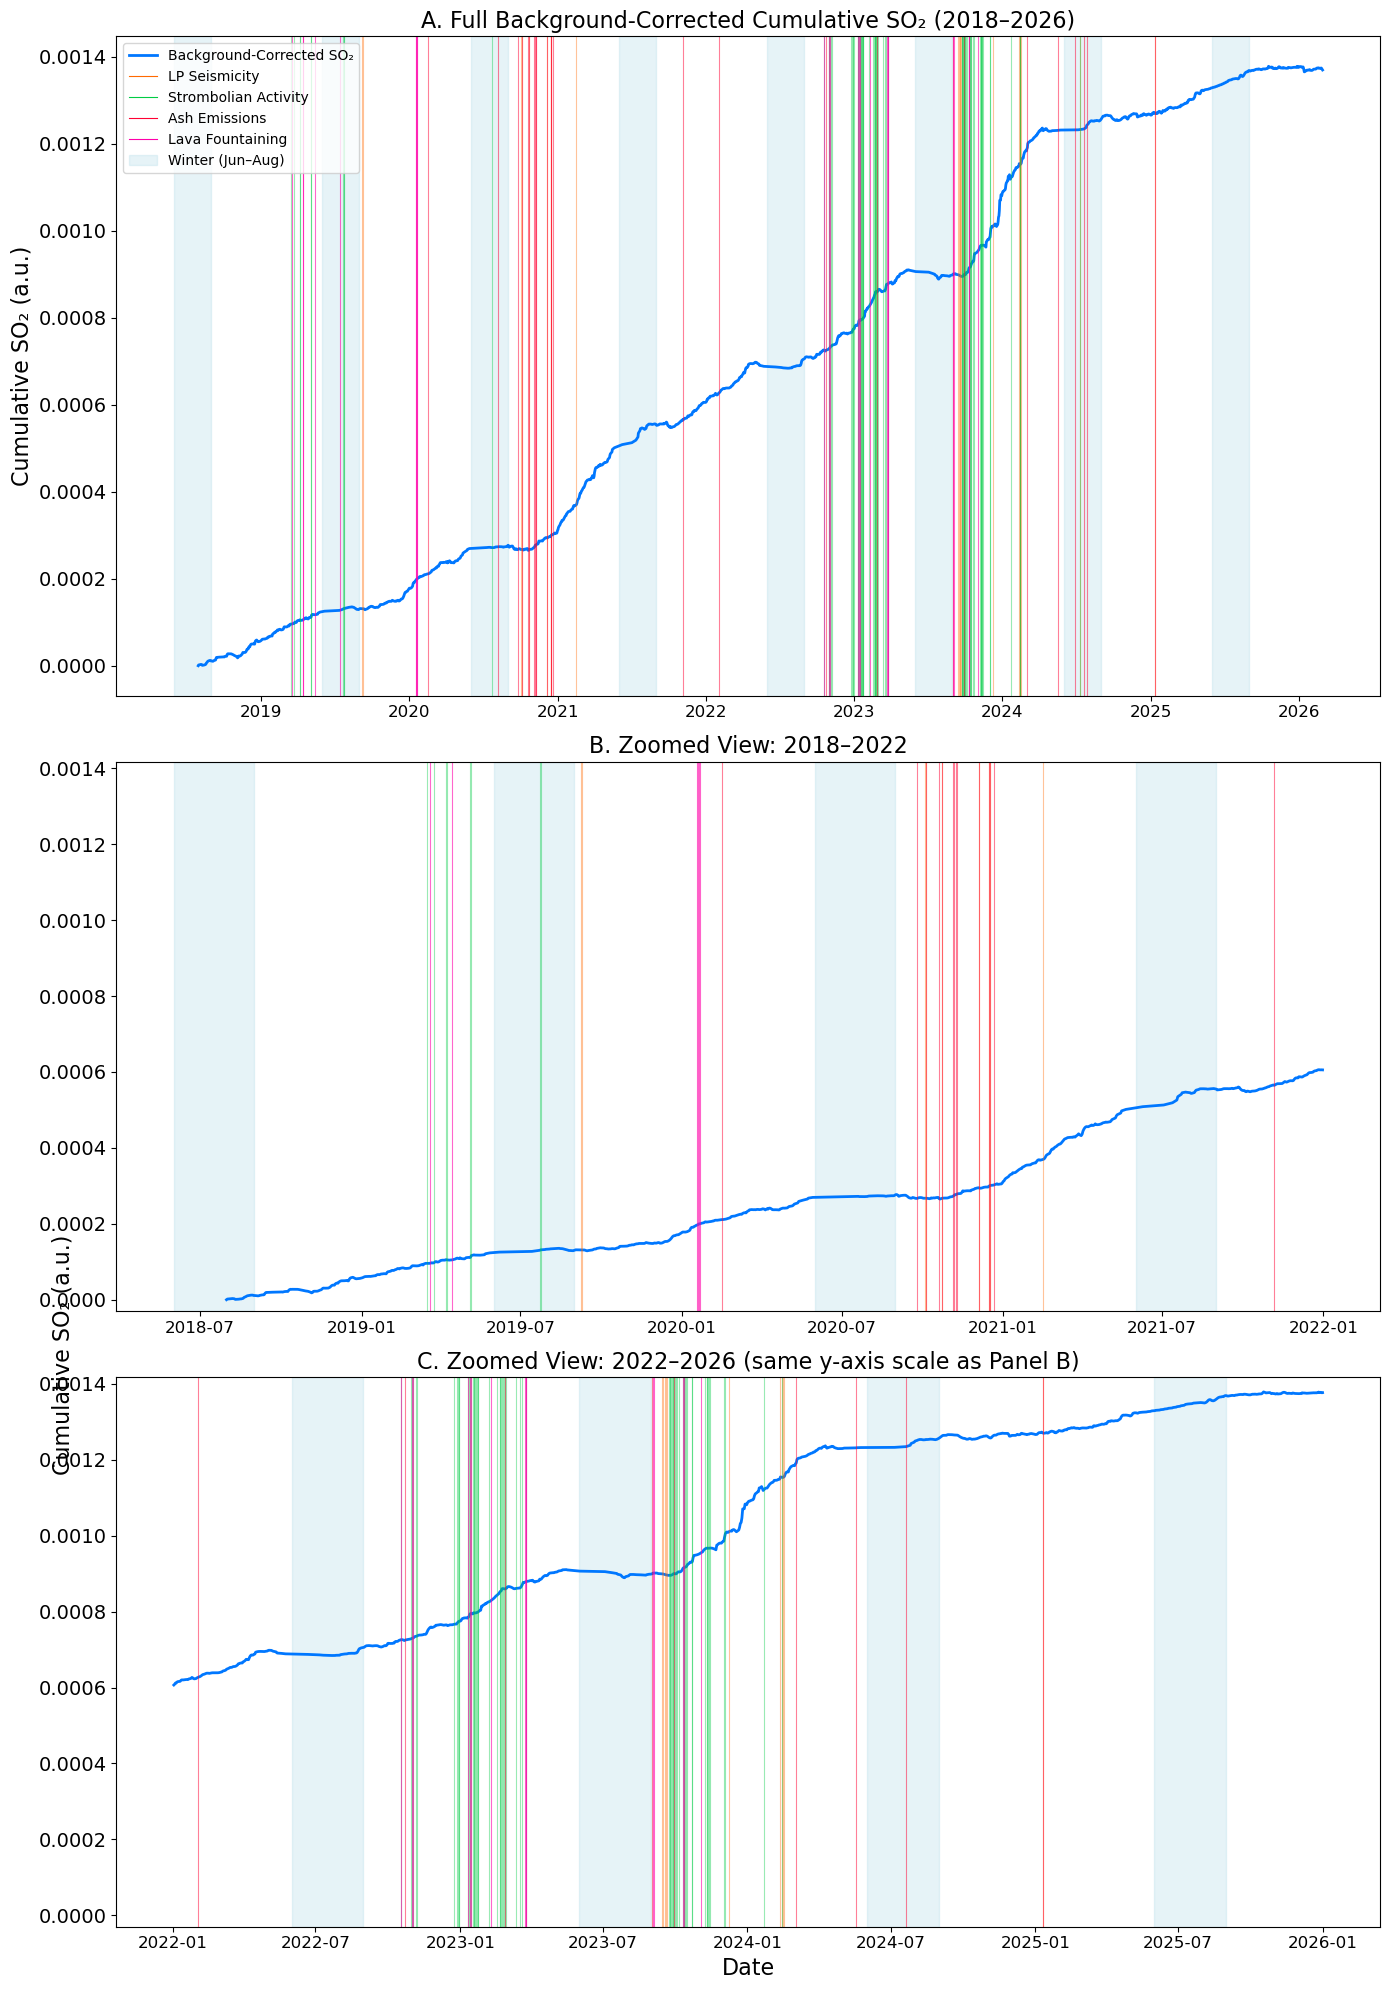

In [104]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

# --- Split datasets ---
df_1 = df[(df['date'] >= '2018-01-01') & (df['date'] < '2022-01-01')]
df_2 = df[(df['date'] >= '2022-01-01') & (df['date'] <= '2026-01-01')]

# --- Convert event dates ---
strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

# --- High‑impact vivid colours ---
SO2_col   = '#0077FF'   # electric blue
LP_col    = '#FF6A00'   # vivid orange
STROM_col = '#00CC44'   # neon green
ASH_col   = '#FF0033'   # vivid red
FNT_col   = '#FF00AA'   # hot magenta

# --- Legend elements ---
legend_elements = [
    Line2D([0], [0], color=SO2_col,   lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=LP_col,    lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col, lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,   lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,   lw=0.8, label='Lava Fountaining'),
    mpatches.Patch(color='lightblue', alpha=0.3, label='Winter (Jun–Aug)')
]

# --- Create 3-panel figure (taller for readability) ---
fig, axes = plt.subplots(3, 1, figsize=(14, 20),
                         gridspec_kw={'height_ratios': [1.2, 1, 1]})

# Increase font sizes for readability
for ax in axes:
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=12)

# ============================================================
# PANEL A — FULL TIME SERIES (2018–2026)
# ============================================================
ax = axes[0]
ax.plot(df['date'], df['cumulative_true_volcano'], lw=2, color=SO2_col)

for year in range(2018, 2026):
    ax.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
               color='lightblue', alpha=0.3, zorder=0)

for d in lp_dt: ax.axvline(d, color=LP_col, alpha=0.4, lw=0.8)
for d in strombolian_dt: ax.axvline(d, color=STROM_col, alpha=0.4, lw=0.8)
for d in ash_dt: ax.axvline(d, color=ASH_col, alpha=0.5, lw=0.8)
for d in lava_fountain_dt: ax.axvline(d, color=FNT_col, alpha=0.6, lw=0.8)

ax.set_title("A. Full Background-Corrected Cumulative SO₂ (2018–2026)", fontsize=16)
ax.set_ylabel("Cumulative SO₂ (a.u.)", fontsize=16)
ax.legend(handles=legend_elements, loc='upper left')

# ============================================================
# PANEL B — ZOOM 2018–2022
# ============================================================
ax = axes[1]
ax.plot(df_1['date'], df_1['cumulative_true_volcano'], lw=2, color=SO2_col)

for year in range(2018, 2022):
    ax.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
               color='lightblue', alpha=0.3, zorder=0)

for d in lp_dt:
    if d in df_1['date'].values: ax.axvline(d, color=LP_col, alpha=0.4, lw=0.8)
for d in strombolian_dt:
    if d in df_1['date'].values: ax.axvline(d, color=STROM_col, alpha=0.4, lw=0.8)
for d in ash_dt:
    if d in df_1['date'].values: ax.axvline(d, color=ASH_col, alpha=0.5, lw=0.8)
for d in lava_fountain_dt:
    if d in df_1['date'].values: ax.axvline(d, color=FNT_col, alpha=0.6, lw=0.8)

ax.set_title("B. Zoomed View: 2018–2022", fontsize=16)

# ============================================================
# PANEL C — ZOOM 2022–2026
# ============================================================
ax = axes[2]
ax.plot(df_2['date'], df_2['cumulative_true_volcano'], lw=2, color=SO2_col)

for year in range(2022, 2026):
    ax.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
               color='lightblue', alpha=0.3, zorder=0)

for d in lp_dt:
    if d in df_2['date'].values: ax.axvline(d, color=LP_col, alpha=0.4, lw=0.8)
for d in strombolian_dt:
    if d in df_2['date'].values: ax.axvline(d, color=STROM_col, alpha=0.4, lw=0.8)
for d in ash_dt:
    if d in df_2['date'].values: ax.axvline(d, color=ASH_col, alpha=0.5, lw=0.8)
for d in lava_fountain_dt:
    if d in df_2['date'].values: ax.axvline(d, color=FNT_col, alpha=0.6, lw=0.8)

ax.set_title("C. Zoomed View: 2022–2026 (same y-axis scale as Panel B)", fontsize=16)
ax.set_xlabel("Date", fontsize=16)

# ============================================================
# MATCH Y‑LIMITS BETWEEN PANELS B & C
# ============================================================
ymin = min(axes[1].get_ylim()[0], axes[2].get_ylim()[0])
ymax = max(axes[1].get_ylim()[1], axes[2].get_ylim()[1])
axes[1].set_ylim(ymin, ymax)
axes[2].set_ylim(ymin, ymax)

# ============================================================
# SHARED Y‑AXIS LABEL FOR PANELS B & C
# ============================================================
fig.text(0.04, 0.32, 'Cumulative SO₂ (a.u.)', va='center',
         rotation='vertical', fontsize=16)

plt.tight_layout()
plt.show()


In [106]:
# --- Diagnostics ---
print("NaNs per column after interpolation:")
print(df.isna().sum())

print("\nFirst few rows of key columns:")
print(df[['date', 'volcano', 'clear_3', 'cumulative_true_volcano']].head(10))

print("\nLast few rows:")
print(df[['date', 'volcano', 'clear_3', 'cumulative_true_volcano']].tail(10))

NaNs per column after interpolation:
Unnamed: 0                 1
date                       0
volcano                    6
clear_1                    3
clear_2                    4
clear_3                    4
clear_4                    7
clear_5                    8
clear_6                    2
clear_7                    7
clear_8                    3
cumulative_so2             6
volcano_interpolated       6
cumulative_volcano         6
cumulative_clear_1         3
cumulative_clear_2         4
cumulative_clear_3         4
cumulative_clear_4         7
cumulative_clear_5         8
cumulative_clear_6         2
cumulative_clear_7         7
cumulative_clear_8         3
cumulative_true_volcano    6
dtype: int64

First few rows of key columns:
        date       volcano       clear_3  cumulative_true_volcano
0 2018-07-11           NaN           NaN                      NaN
1 2018-07-16           NaN           NaN                      NaN
2 2018-07-21           NaN           NaN             

In [107]:
# Replace zeros with NaN
df.replace(0, np.nan, inplace=True)

# Interpolate interior NaNs, then fill edges that interpolation can't reach
df.interpolate(method='linear', inplace=True)
df.ffill(inplace=True)   # fill any leading NaNs
df.bfill(inplace=True)   # fill any trailing NaNs

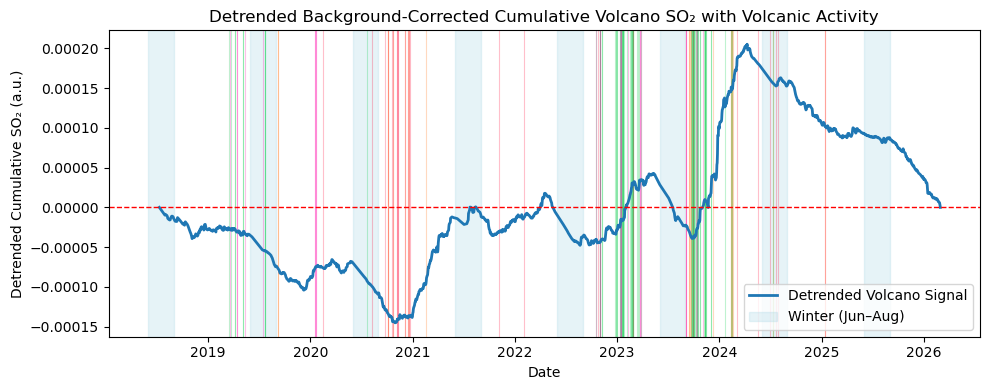

In [108]:
import datetime as dt
# --- Convert dates to matplotlib numeric format ---
dates_num = mdates.date2num(df['date'])

# --- Linear trend from start to end ---
start_val = df['cumulative_true_volcano'].iloc[0]
end_val = df['cumulative_true_volcano'].iloc[-1]

linear_trend = start_val + (end_val - start_val) * (
    (dates_num - dates_num[0]) / (dates_num[-1] - dates_num[0])
)

# --- Detrend: subtract linear trend ---
df['detrended_true_volcano'] = df['cumulative_true_volcano'] - linear_trend

# --- Plot detrended signal ---
fig, ax = plt.subplots(figsize=(10,4))

for d in lp_dt: ax.axvline(d, color=LP_col, alpha=0.25, lw=0.8)
for d in strombolian_dt: ax.axvline(d, color=STROM_col, alpha=0.25, lw=0.8)
for d in ash_dt: ax.axvline(d, color=ASH_col, alpha=0.25, lw=0.8)
for d in lava_fountain_dt: ax.axvline(d, color=FNT_col, alpha=0.25, lw=0.8)

ax.plot(df['date'], df['detrended_true_volcano'], lw=2, label='Detrended Volcano Signal')

# --- Seasonal highlights ---
years = range(2018, 2026)
winter_labeled = False
for year in years:
    # Winter: December current year to February next year
    label = 'Winter (Jun–Aug)' if not winter_labeled else None
    ax.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
               color='lightblue', alpha=0.3, label=label)
    winter_labeled = True

# Zero reference line
ax.axhline(0, color='r', linestyle='--', lw=1)

# Date formatting
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.set_xlabel('Date')
ax.set_ylabel('Detrended Cumulative SO₂ (a.u.)')
ax.set_title('Detrended Background-Corrected Cumulative Volcano SO₂ with Volcanic Activity')
ax.legend()

plt.tight_layout()
plt.show()


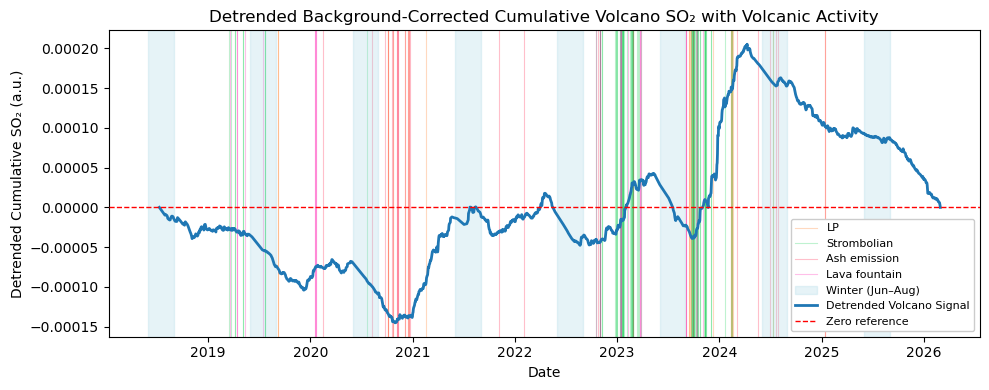

In [109]:
import datetime as dt

# --- Convert dates to matplotlib numeric format ---
dates_num = mdates.date2num(df['date'])

# --- Linear trend from start to end ---
start_val = df['cumulative_true_volcano'].iloc[0]
end_val = df['cumulative_true_volcano'].iloc[-1]

linear_trend = start_val + (end_val - start_val) * (
    (dates_num - dates_num[0]) / (dates_num[-1] - dates_num[0])
)

# --- Detrend: subtract linear trend ---
df['detrended_true_volcano'] = df['cumulative_true_volcano'] - linear_trend

# --- Create figure FIRST ---
fig, ax = plt.subplots(figsize=(10, 4))

# --- Activity vertical lines BEHIND everything (first entry only gets label) ---
for i, d in enumerate(lp_dt):
    ax.axvline(d, color=LP_col, alpha=0.25, lw=0.8, zorder=1,
               label='LP' if i == 0 else None)
for i, d in enumerate(strombolian_dt):
    ax.axvline(d, color=STROM_col, alpha=0.25, lw=0.8, zorder=1,
               label='Strombolian' if i == 0 else None)
for i, d in enumerate(ash_dt):
    ax.axvline(d, color=ASH_col, alpha=0.25, lw=0.8, zorder=1,
               label='Ash emission' if i == 0 else None)
for i, d in enumerate(lava_fountain_dt):
    ax.axvline(d, color=FNT_col, alpha=0.25, lw=0.8, zorder=1,
               label='Lava fountain' if i == 0 else None)

# --- Seasonal highlights ---
years = range(2018, 2026)
winter_labeled = False
for year in years:
    label = 'Winter (Jun–Aug)' if not winter_labeled else None
    ax.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
               color='lightblue', alpha=0.3, label=label, zorder=2)
    winter_labeled = True

# --- Plot detrended signal ON TOP ---
ax.plot(df['date'], df['detrended_true_volcano'], lw=2,
        label='Detrended Volcano Signal', zorder=3)

# Zero reference line
ax.axhline(0, color='r', linestyle='--', lw=1, zorder=3, label='Zero reference')

# Date formatting
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.set_xlabel('Date')
ax.set_ylabel('Detrended Cumulative SO₂ (a.u.)')
ax.set_title('Detrended Background-Corrected Cumulative Volcano SO₂ with Volcanic Activity')
ax.legend(loc='best', fontsize=8, framealpha=1)

plt.tight_layout()
plt.savefig("figuredetrended.png", dpi=800, bbox_inches='tight')
plt.show()


C:\Users\davie\AppData\Local\Temp\ipykernel_21440\1471260156.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


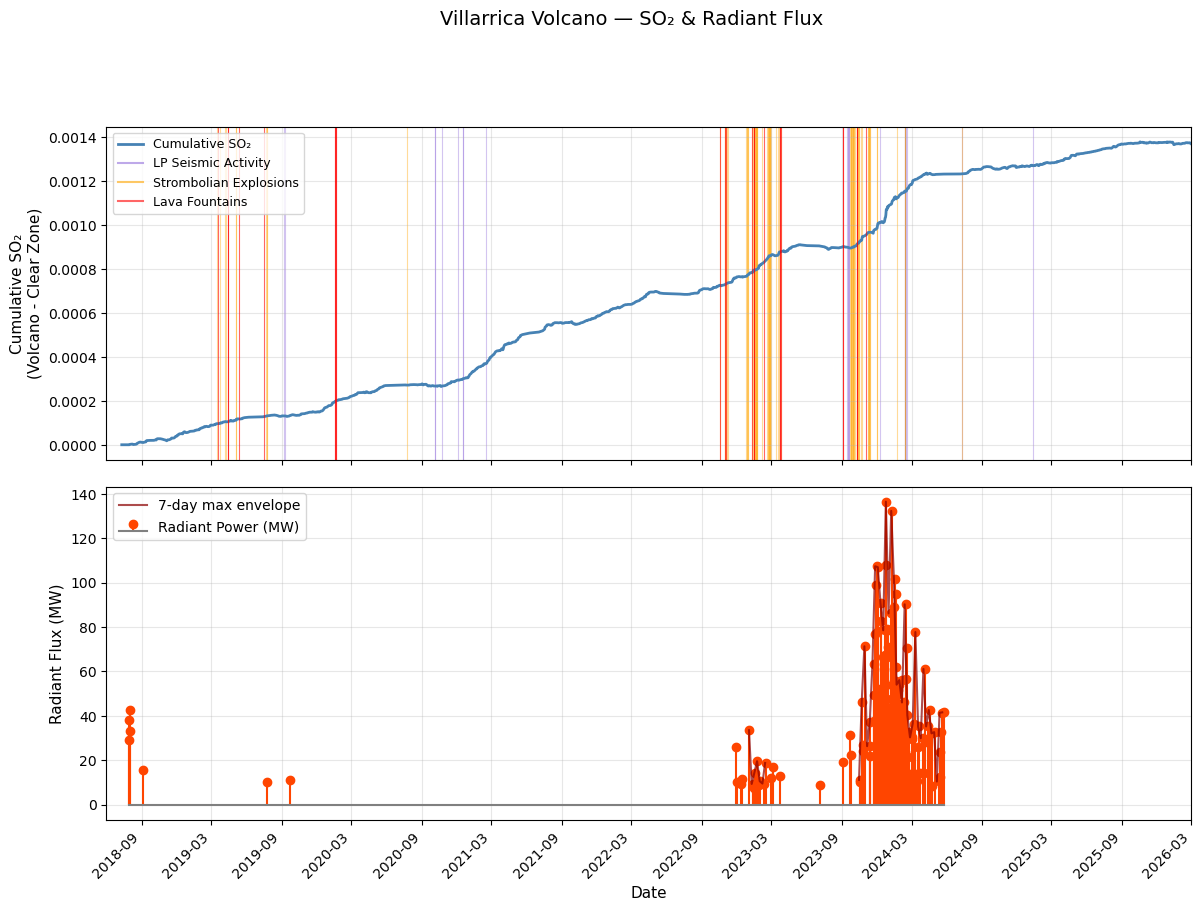

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import StringIO

# --- Load MODVOLC data ---
modvolc_raw = """UNIX_Time	Count	Radiance	Power
1532922900	1	1.676	29.179
1532962800	1	2.237	37.913
1533094800	2	1.998	33.009
1533189899	1	2.376	42.612
1535954699	1	0.969	15.657
1563946500	1	0.666	10.213
1569209099	1	0.742	11.279
1669731599	1	1.817	25.822
1669952400	1	0.761	10.285
1670909700	1	0.707	9.201
1670998800	1	0.826	11.450
1672630800	1	2.023	33.508
1673495999	1	0.732	8.570
1673590800	1	0.744	9.310
1673839499	1	0.637	7.313
1674011400	1	1.008	14.325
1674444000	2	1.535	19.558
1674876600	1	0.728	9.033
1675048499	1	0.808	10.545
1676085299	1	0.752	9.486
1676517899	1	1.241	18.728
1677554699	1	0.874	11.792
1677987300	1	1.114	16.777
1679628600	1	0.911	12.941
1688698800	1	0.594	8.729
1693710899	1	1.170	19.368
1695480600	1	1.931	31.320
1695495599	1	1.458	22.411
1697610299	1	0.707	10.351
1697685899	1	0.754	11.150
1698118200	2	2.782	46.379
1698329999	1	1.620	23.981
1698346799	1	1.798	26.913
1698722400	3	4.267	71.345
1699799100	1	1.843	26.319
1699856699	1	1.339	21.679
1699988700	1	2.470	37.356
1700805000	4	4.123	63.413
1700835599	1	2.438	37.560
1700893800	2	2.991	49.324
1701065699	2	4.441	76.679
1701228299	2	5.604	98.752
1701237600	2	1.783	26.443
1701326700	1	2.789	49.084
1701399899	2	6.116	107.397
1701660600	4	6.528	106.988
1701670200	2	4.574	78.125
1701891299	1	2.086	28.158
1702063200	1	2.869	42.954
1702093200	3	3.446	52.173
1702132799	1	1.581	20.098
1702264800	2	5.238	90.803
1702275000	2	4.829	82.945
1702304700	1	2.511	37.676
1702446900	1	0.871	12.300
1702476300	1	1.578	20.189
1702565400	1	1.739	23.097
1702869000	1	3.733	66.456
1703140200	2	3.679	61.210
1703272199	1	4.156	67.275
1703341199	1	4.673	78.553
1703473200	2	7.656	136.503
1703484000	1	5.923	107.783
1703562000	1	0.842	11.816
1703572800	1	1.975	33.166
1703704800	1	2.541	36.756
1703744699	2	2.400	37.037
1703773799	2	5.227	79.233
1703905499	2	4.185	70.901
1703945400	2	5.196	78.655
1704166200	2	2.652	40.669
1704349200	4	2.395	26.260
1704377700	1	1.378	14.931
1704509700	3	5.339	86.189
1704681599	3	4.274	66.599
1704693000	3	4.372	68.377
1704721499	2	3.696	47.617
1704741900	1	3.043	43.899
1704781800	3	7.741	132.354
1704953699	2	3.357	53.945
1705202699	1	1.066	15.421
1705214400	1	2.163	36.129
1705242599	1	1.641	19.906
1705346400	1	5.419	89.111
1705374600	2	3.474	55.668
1705414500	2	6.544	101.458
1705635300	4	6.046	94.699
1705646999	1	0.863	11.559
1705674900	1	1.820	23.288
1705730100	2	3.441	55.532
1705806899	2	3.775	61.894
1705846799	1	3.168	48.751
1706251500	1	0.691	8.309
1706279100	2	3.904	51.549
1706383500	1	1.991	24.322
1706411099	2	3.360	54.051
1706767200	2	2.358	35.188
1706843400	2	2.881	44.998
1706988000	1	2.923	41.746
1707015300	1	1.998	33.036
1707027899	1	3.215	56.075
1707055200	1	2.965	45.194
1707104100	2	1.706	22.790
1707420600	1	2.949	42.239
1707487500	1	3.010	46.028
1707619500	2	1.763	23.867
1707748199	1	1.825	23.640
1708051800	2	5.275	90.244
1708065000	1	3.253	56.793
1708236899	2	4.230	70.569
1708312499	1	2.379	40.236
1708352399	1	1.704	21.351
1708669499	2	2.229	32.750
1708930199	1	0.833	11.055
1709273699	2	2.024	29.567
1709388900	1	2.074	30.301
1709534400	1	0.987	14.311
1709706299	1	2.161	36.500
1710138900	2	4.574	77.762
1710482699	1	0.781	10.418
1710743400	2	1.835	25.995
1710817800	1	2.089	35.205
1711250400	1	0.976	14.169
1711780200	2	2.043	29.926
1711952099	1	0.953	14.240
1712286600	3	3.819	61.134
1712384699	2	1.888	28.141
1712890800	1	2.058	35.214
1713421499	2	2.653	42.599
1713854100	2	2.098	32.110
1713927300	1	0.640	8.414
1714531500	2	2.061	32.652
1715396100	1	0.717	10.401
1715656800	1	0.827	12.480
1715667000	1	1.433	23.795
1715927700	2	2.071	32.564
1716099299	1	2.362	41.353
1716492000	1	2.540	41.567"""

mv = pd.read_csv(StringIO(modvolc_raw), sep='\t')
mv['date'] = pd.to_datetime(mv['UNIX_Time'], unit='s')
mv = mv.sort_values('date')

# --- Stacked plot: SO2 on top, radiant flux below, shared x-axis ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                gridspec_kw={'hspace': 0.08})

# Top panel: cumulative SO2 (from your existing df)
ax1.plot(df['date'], df['cumulative_true_volcano'], lw=2,
         color='steelblue', label='Cumulative SO₂')
ax1.set_ylabel('Cumulative SO₂\n(Volcano - Clear Zone)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Volcanic activity dates ---
strombolian_dates = [
    '17/03/2019','24/03/2019','07/04/2019','08/04/2019','05/05/2019','06/05/2019',
    '23/07/2019','24/07/2019','25/07/2019','23/07/2020','18/10/2022','31/10/2022',
    '01/11/2022','02/11/2022','06/11/2022','07/11/2022','24/12/2022','28/12/2022',
    '29/12/2022','30/12/2022','31/12/2022','11/01/2023','12/01/2023','14/01/2023',
    '15/01/2023','17/01/2023','18/01/2023','19/01/2023','20/01/2023','21/01/2023',
    '22/01/2023','23/01/2023','24/01/2023','06/02/2023','17/02/2023','20/02/2023',
    '21/02/2023','22/02/2023','23/02/2023','24/02/2023','25/02/2023','26/02/2023',
    '27/02/2023','28/02/2023','13/03/2023','18/03/2023','21/03/2023','26/03/2023',
    '23/09/2023','24/09/2023','25/09/2023','26/09/2023','27/09/2023','28/09/2023',
    '29/09/2023','30/09/2023','01/10/2023','02/10/2023','03/10/2023','06/10/2023',
    '11/10/2023','12/10/2023','13/10/2023','14/10/2023','15/10/2023','16/10/2023',
    '22/10/2023','23/10/2023','08/11/2023','09/11/2023','10/11/2023','11/11/2023',
    '12/11/2023','13/11/2023','14/11/2023','02/12/2023','03/12/2023','22/01/2024',
    '13/02/2024','14/02/2024','10/07/2024'
]

lava_fountain_dates = [
    '20/03/2019','14/04/2019','15/04/2019','14/05/2019','16/07/2019','18/01/2020',
    '19/01/2020','20/01/2020','22/01/2020','18/10/2022','01/11/2022','02/11/2022',
    '11/01/2023','14/01/2023','15/01/2023','09/02/2023','24/03/2023','25/03/2023',
    '26/03/2023','03/09/2023','04/09/2023','11/10/2023','12/10/2023','03/11/2023'
]
# --- Add LP seismic dates ---
lp_dates = [
    '08/09/2019','09/09/2019','04/10/2020','05/10/2020','23/10/2020',
    '05/12/2020','16/12/2020','17/12/2020','16/02/2021','15/09/2023',
    '16/09/2023','18/09/2023','20/09/2023','21/09/2023','09/12/2023',
    '12/02/2024','13/02/2024','14/02/2024','15/02/2024','17/02/2024',
    '10/07/2024','11/01/2025'
]

lp_dt = pd.to_datetime(lp_dates, dayfirst=True)
strombolian_dt = pd.to_datetime(strombolian_dates, dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)

# Draw LP lines on SO2 panel (below the others so volcanic events stay visible)
for date in lp_dt:
    ax1.axvline(date, color='mediumpurple', alpha=0.4, lw=0.8, zorder=0)

for date in strombolian_dt:
    ax1.axvline(date, color='orange', alpha=0.4, lw=0.8, zorder=1)

for date in lava_fountain_dt:
    ax1.axvline(date, color='red', alpha=0.6, lw=0.8, zorder=2)

# --- Updated legend with LP included ---
proxy_lp    = Line2D([0], [0], color='mediumpurple', alpha=0.6, lw=1.5, label='LP Seismic Activity')
proxy_strom = Line2D([0], [0], color='orange',       alpha=0.6, lw=1.5, label='Strombolian Explosions')
proxy_lava  = Line2D([0], [0], color='red',          alpha=0.6, lw=1.5, label='Lava Fountains')

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles=handles + [proxy_lp, proxy_strom, proxy_lava], loc='upper left', fontsize=9)

# Bottom panel: MODVOLC radiant flux as stem/scatter
ax2.stem(mv['date'], mv['Power'], linefmt='orangered', markerfmt='o',
         basefmt='gray', label='Radiant Power (MW)')

# Optional: overlay a rolling max to show activity bursts more clearly
mv_daily = mv.set_index('date')['Power'].resample('7D').max()
ax2.plot(mv_daily.index, mv_daily.values, color='darkred',
         lw=1.5, alpha=0.7, label='7-day max envelope')

ax2.set_ylabel('Radiant Flux (MW)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

# Shared x-axis formatting
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.suptitle('Villarrica Volcano — SO₂ & Radiant Flux', fontsize=14, y=1.01)
ax1.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2026-03-01'))

plt.tight_layout()
plt.show()

C:\Users\davie\AppData\Local\Temp\ipykernel_21440\770290175.py:257: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


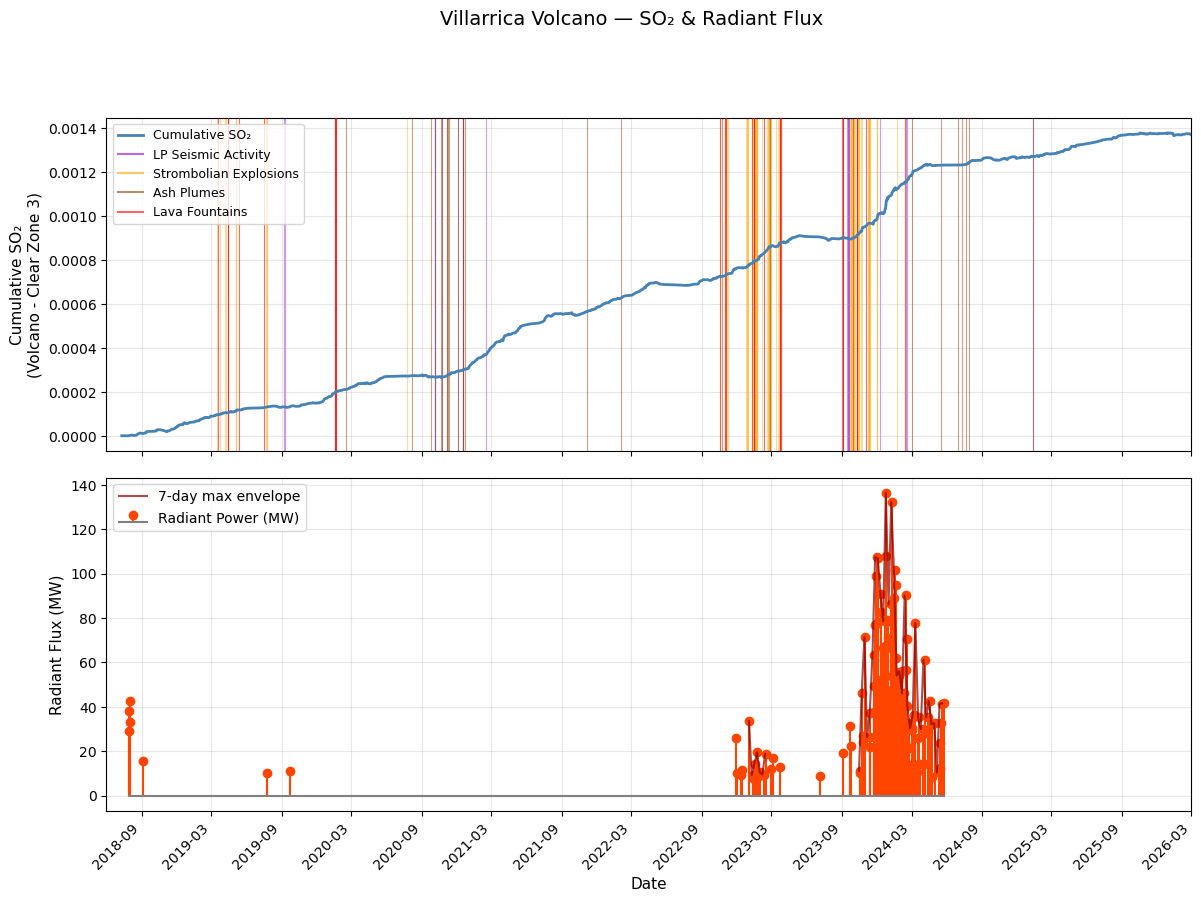

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from io import StringIO
from scipy import signal as scipy_signal

# =============================================================================
# --- MODVOLC DATA ---
# =============================================================================
modvolc_raw = """UNIX_Time	Count	Radiance	Power
1532922900	1	1.676	29.179
1532962800	1	2.237	37.913
1533094800	2	1.998	33.009
1533189899	1	2.376	42.612
1535954699	1	0.969	15.657
1563946500	1	0.666	10.213
1569209099	1	0.742	11.279
1669731599	1	1.817	25.822
1669952400	1	0.761	10.285
1670909700	1	0.707	9.201
1670998800	1	0.826	11.450
1672630800	1	2.023	33.508
1673495999	1	0.732	8.570
1673590800	1	0.744	9.310
1673839499	1	0.637	7.313
1674011400	1	1.008	14.325
1674444000	2	1.535	19.558
1674876600	1	0.728	9.033
1675048499	1	0.808	10.545
1676085299	1	0.752	9.486
1676517899	1	1.241	18.728
1677554699	1	0.874	11.792
1677987300	1	1.114	16.777
1679628600	1	0.911	12.941
1688698800	1	0.594	8.729
1693710899	1	1.170	19.368
1695480600	1	1.931	31.320
1695495599	1	1.458	22.411
1697610299	1	0.707	10.351
1697685899	1	0.754	11.150
1698118200	2	2.782	46.379
1698329999	1	1.620	23.981
1698346799	1	1.798	26.913
1698722400	3	4.267	71.345
1699799100	1	1.843	26.319
1699856699	1	1.339	21.679
1699988700	1	2.470	37.356
1700805000	4	4.123	63.413
1700835599	1	2.438	37.560
1700893800	2	2.991	49.324
1701065699	2	4.441	76.679
1701228299	2	5.604	98.752
1701237600	2	1.783	26.443
1701326700	1	2.789	49.084
1701399899	2	6.116	107.397
1701660600	4	6.528	106.988
1701670200	2	4.574	78.125
1701891299	1	2.086	28.158
1702063200	1	2.869	42.954
1702093200	3	3.446	52.173
1702132799	1	1.581	20.098
1702264800	2	5.238	90.803
1702275000	2	4.829	82.945
1702304700	1	2.511	37.676
1702446900	1	0.871	12.300
1702476300	1	1.578	20.189
1702565400	1	1.739	23.097
1702869000	1	3.733	66.456
1703140200	2	3.679	61.210
1703272199	1	4.156	67.275
1703341199	1	4.673	78.553
1703473200	2	7.656	136.503
1703484000	1	5.923	107.783
1703562000	1	0.842	11.816
1703572800	1	1.975	33.166
1703704800	1	2.541	36.756
1703744699	2	2.400	37.037
1703773799	2	5.227	79.233
1703905499	2	4.185	70.901
1703945400	2	5.196	78.655
1704166200	2	2.652	40.669
1704349200	4	2.395	26.260
1704377700	1	1.378	14.931
1704509700	3	5.339	86.189
1704681599	3	4.274	66.599
1704693000	3	4.372	68.377
1704721499	2	3.696	47.617
1704741900	1	3.043	43.899
1704781800	3	7.741	132.354
1704953699	2	3.357	53.945
1705202699	1	1.066	15.421
1705214400	1	2.163	36.129
1705242599	1	1.641	19.906
1705346400	1	5.419	89.111
1705374600	2	3.474	55.668
1705414500	2	6.544	101.458
1705635300	4	6.046	94.699
1705646999	1	0.863	11.559
1705674900	1	1.820	23.288
1705730100	2	3.441	55.532
1705806899	2	3.775	61.894
1705846799	1	3.168	48.751
1706251500	1	0.691	8.309
1706279100	2	3.904	51.549
1706383500	1	1.991	24.322
1706411099	2	3.360	54.051
1706767200	2	2.358	35.188
1706843400	2	2.881	44.998
1706988000	1	2.923	41.746
1707015300	1	1.998	33.036
1707027899	1	3.215	56.075
1707055200	1	2.965	45.194
1707104100	2	1.706	22.790
1707420600	1	2.949	42.239
1707487500	1	3.010	46.028
1707619500	2	1.763	23.867
1707748199	1	1.825	23.640
1708051800	2	5.275	90.244
1708065000	1	3.253	56.793
1708236899	2	4.230	70.569
1708312499	1	2.379	40.236
1708352399	1	1.704	21.351
1708669499	2	2.229	32.750
1708930199	1	0.833	11.055
1709273699	2	2.024	29.567
1709388900	1	2.074	30.301
1709534400	1	0.987	14.311
1709706299	1	2.161	36.500
1710138900	2	4.574	77.762
1710482699	1	0.781	10.418
1710743400	2	1.835	25.995
1710817800	1	2.089	35.205
1711250400	1	0.976	14.169
1711780200	2	2.043	29.926
1711952099	1	0.953	14.240
1712286600	3	3.819	61.134
1712384699	2	1.888	28.141
1712890800	1	2.058	35.214
1713421499	2	2.653	42.599
1713854100	2	2.098	32.110
1713927300	1	0.640	8.414
1714531500	2	2.061	32.652
1715396100	1	0.717	10.401
1715656800	1	0.827	12.480
1715667000	1	1.433	23.795
1715927700	2	2.071	32.564
1716099299	1	2.362	41.353
1716492000	1	2.540	41.567"""

mv = pd.read_csv(StringIO(modvolc_raw), sep='\t')
mv['date'] = pd.to_datetime(mv['UNIX_Time'], unit='s')
mv = mv.sort_values('date')

# =============================================================================
# --- VOLCANIC ACTIVITY DATES ---
# =============================================================================
strombolian_dates = [
    '17/03/2019','24/03/2019','07/04/2019','08/04/2019','05/05/2019','06/05/2019',
    '23/07/2019','24/07/2019','25/07/2019','23/07/2020','18/10/2022','31/10/2022',
    '01/11/2022','02/11/2022','06/11/2022','07/11/2022','24/12/2022','28/12/2022',
    '29/12/2022','30/12/2022','31/12/2022','11/01/2023','12/01/2023','14/01/2023',
    '15/01/2023','17/01/2023','18/01/2023','19/01/2023','20/01/2023','21/01/2023',
    '22/01/2023','23/01/2023','24/01/2023','06/02/2023','17/02/2023','20/02/2023',
    '21/02/2023','22/02/2023','23/02/2023','24/02/2023','25/02/2023','26/02/2023',
    '27/02/2023','28/02/2023','13/03/2023','18/03/2023','21/03/2023','26/03/2023',
    '23/09/2023','24/09/2023','25/09/2023','26/09/2023','27/09/2023','28/09/2023',
    '29/09/2023','30/09/2023','01/10/2023','02/10/2023','03/10/2023','06/10/2023',
    '11/10/2023','12/10/2023','13/10/2023','14/10/2023','15/10/2023','16/10/2023',
    '22/10/2023','23/10/2023','08/11/2023','09/11/2023','10/11/2023','11/11/2023',
    '12/11/2023','13/11/2023','14/11/2023','02/12/2023','03/12/2023','22/01/2024',
    '13/02/2024','14/02/2024','10/07/2024'
]

lava_fountain_dates = [
    '20/03/2019','14/04/2019','15/04/2019','14/05/2019','16/07/2019','18/01/2020',
    '19/01/2020','20/01/2020','22/01/2020','18/10/2022','01/11/2022','02/11/2022',
    '11/01/2023','14/01/2023','15/01/2023','09/02/2023','24/03/2023','25/03/2023',
    '26/03/2023','03/09/2023','04/09/2023','11/10/2023','12/10/2023','03/11/2023'
]

lp_dates = [
    '08/09/2019','09/09/2019','04/10/2020','05/10/2020','23/10/2020',
    '05/12/2020','16/12/2020','17/12/2020','16/02/2021','15/09/2023',
    '16/09/2023','18/09/2023','20/09/2023','21/09/2023','09/12/2023',
    '12/02/2024','13/02/2024','14/02/2024','15/02/2024','17/02/2024',
    '10/07/2024','11/01/2025'
]

ash_dates = [
    '07/08/2020','25/09/2020','05/10/2020','20/10/2020','23/10/2020',
    '05/11/2020','06/11/2020','08/11/2020','10/11/2020','05/12/2020',
    '16/12/2020','17/12/2020','22/12/2020','16/02/2020','06/11/2021',
    '02/02/2022','23/10/2022','27/02/2023','02/09/2023','30/09/2023',
    '03/03/2024','18/05/2024','29/06/2024','21/07/2024','29/07/2024',
    '11/01/2025'
]

strombolian_dt  = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt           = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt          = pd.to_datetime(ash_dates,            dayfirst=True)

# =============================================================================
# --- PLOT ---
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                gridspec_kw={'hspace': 0.08})

# --- Top panel: Cumulative SO2 ---
ax1.plot(df['date'], df['cumulative_true_volcano'], lw=2,
         color='steelblue', label='Cumulative SO₂', zorder=5)

# Vertical event lines (ascending zorder = drawn on top)
for date in lp_dt:
    ax1.axvline(date, color='darkviolet', alpha=0.4, lw=0.8, zorder=0)
for date in strombolian_dt:
    ax1.axvline(date, color='orange',       alpha=0.4, lw=0.8, zorder=1)
for date in ash_dt:
    ax1.axvline(date, color='saddlebrown',  alpha=0.5, lw=0.8, zorder=2)
for date in lava_fountain_dt:
    ax1.axvline(date, color='red',          alpha=0.6, lw=0.8, zorder=3)

ax1.set_ylabel('Cumulative SO₂\n(Volcano - Clear Zone 3)', fontsize=11)
ax1.grid(True, alpha=0.3)

# Legend with proxy artists
proxy_so2   = Line2D([0], [0], color='steelblue',    lw=2,   label='Cumulative SO₂')
proxy_lp    = Line2D([0], [0], color='darkviolet', alpha=0.6, lw=1.5, label='LP Seismic Activity')
proxy_strom = Line2D([0], [0], color='orange',       alpha=0.6, lw=1.5, label='Strombolian Explosions')
proxy_ash   = Line2D([0], [0], color='saddlebrown',  alpha=0.6, lw=1.5, label='Ash Plumes')
proxy_lava  = Line2D([0], [0], color='red',          alpha=0.6, lw=1.5, label='Lava Fountains')
ax1.legend(handles=[proxy_so2, proxy_lp, proxy_strom, proxy_ash, proxy_lava],
           loc='upper left', fontsize=9)

# --- Bottom panel: MODVOLC radiant flux ---
ax2.stem(mv['date'], mv['Power'], linefmt='orangered', markerfmt='o',
         basefmt='gray', label='Radiant Power (MW)')

mv_daily = mv.set_index('date')['Power'].resample('7D').max()
ax2.plot(mv_daily.index, mv_daily.values, color='darkred',
         lw=1.5, alpha=0.7, label='7-day max envelope')

ax2.set_ylabel('Radiant Flux (MW)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

# --- Shared x-axis: 2023-2025, ticks every 6 months ---
ax1.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2026-03-01'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.suptitle('Villarrica Volcano — SO₂ & Radiant Flux', fontsize=14, y=1)
plt.tight_layout()
plt.show()

C:\Users\davie\AppData\Local\Temp\ipykernel_21440\4251332865.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


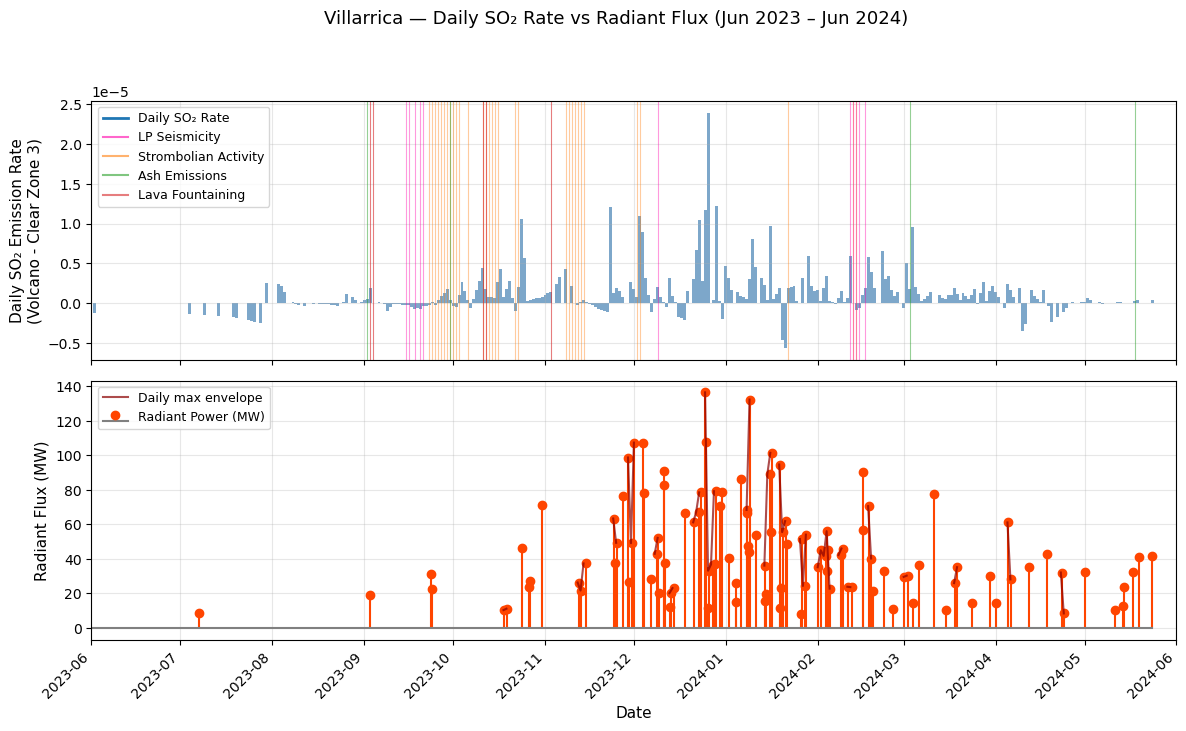

In [125]:
# --- Filter to June 2023 – June 2024 ---
mask = (df['date'] >= '2023-01-01') & (df['date'] <= '2025-01-01')
df_period = df[mask].copy()

# --- Daily SO2 emission rate (difference of cumulative, or raw daily values) ---
df_period = df_period.set_index('date')
df_daily_so2 = df_period['cumulative_true_volcano'].diff()  # daily rate from cumulative

# --- Filter MODVOLC to same period ---
mask_mv = (mv['date'] >= '2023-01-01') & (mv['date'] <= '2025-01-01')
mv_period = mv[mask_mv].copy()

# --- Resample MODVOLC to daily max ---
mv_period_daily = mv_period.set_index('date')['Power'].resample('1D').max()

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={'hspace': 0.08})

# --- Top panel: Daily SO2 emission rate ---
ax1.bar(df_daily_so2.index, df_daily_so2.values,
        color='steelblue', alpha=0.7, width=1.0, label='Daily SO₂ Emission Rate')
ax1.grid(True, alpha=0.3, zorder=0)
ax1.set_ylabel('Daily SO₂ Emission Rate\n(Volcano - Clear Zone 3)', fontsize=11)

# Event lines
for date in strombolian_dt:
    ax1.axvline(date, color=STROM_col, alpha=0.4, lw=0.8)
for date in lava_fountain_dt:
    ax1.axvline(date, color=FNT_col,   alpha=0.6, lw=0.8)
for date in lp_dt:
    ax1.axvline(date, color=LP_col,    alpha=0.4, lw=0.8)
for date in ash_dt:
    ax1.axvline(date, color=ASH_col,   alpha=0.5, lw=0.8)

# Proxy artists
proxy_so2   = Line2D([0], [0], color=SO2_col,   lw=2,              label='Daily SO₂ Rate')
proxy_lp    = Line2D([0], [0], color=LP_col,    lw=1.5, alpha=0.6, label='LP Seismicity')
proxy_strom = Line2D([0], [0], color=STROM_col, lw=1.5, alpha=0.6, label='Strombolian Activity')
proxy_ash   = Line2D([0], [0], color=ASH_col,   lw=1.5, alpha=0.6, label='Ash Emissions')
proxy_lava  = Line2D([0], [0], color=FNT_col,   lw=1.5, alpha=0.6, label='Lava Fountaining')
# proxy_winter = Line2D([0], [0], color='lightblue',  lw=8, alpha=0.5,  label='Winter (Jun–Aug)')
ax1.legend(handles=[proxy_so2, proxy_lp, proxy_strom, proxy_ash, proxy_lava],
           loc='upper left', fontsize=9)

# --- Bottom panel: MODVOLC radiant power ---
ax2.stem(mv_period['date'], mv_period['Power'],
         linefmt='orangered', markerfmt='o', basefmt='gray',
         label='Radiant Power (MW)')

ax2.plot(mv_period_daily.index, mv_period_daily.values,
         color='darkred', lw=1.5, alpha=0.7, label='Daily max envelope')

# ax2.axvspan(pd.Timestamp('2023-06-01'), pd.Timestamp('2023-08-31'),
#             color='lightblue', alpha=0.3)
# ax2.axvspan(pd.Timestamp('2024-06-01'), pd.Timestamp('2024-08-31'),
#             color='lightblue', alpha=0.3)

ax2.set_ylabel('Radiant Flux (MW)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# --- x-axis formatting ---
ax1.set_xlim(pd.Timestamp('2023-06-01'), pd.Timestamp('2024-06-01'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.suptitle('Villarrica — Daily SO₂ Rate vs Radiant Flux (Jun 2023 – Jun 2024)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\davie\AppData\Local\Temp\ipykernel_21440\3151055356.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


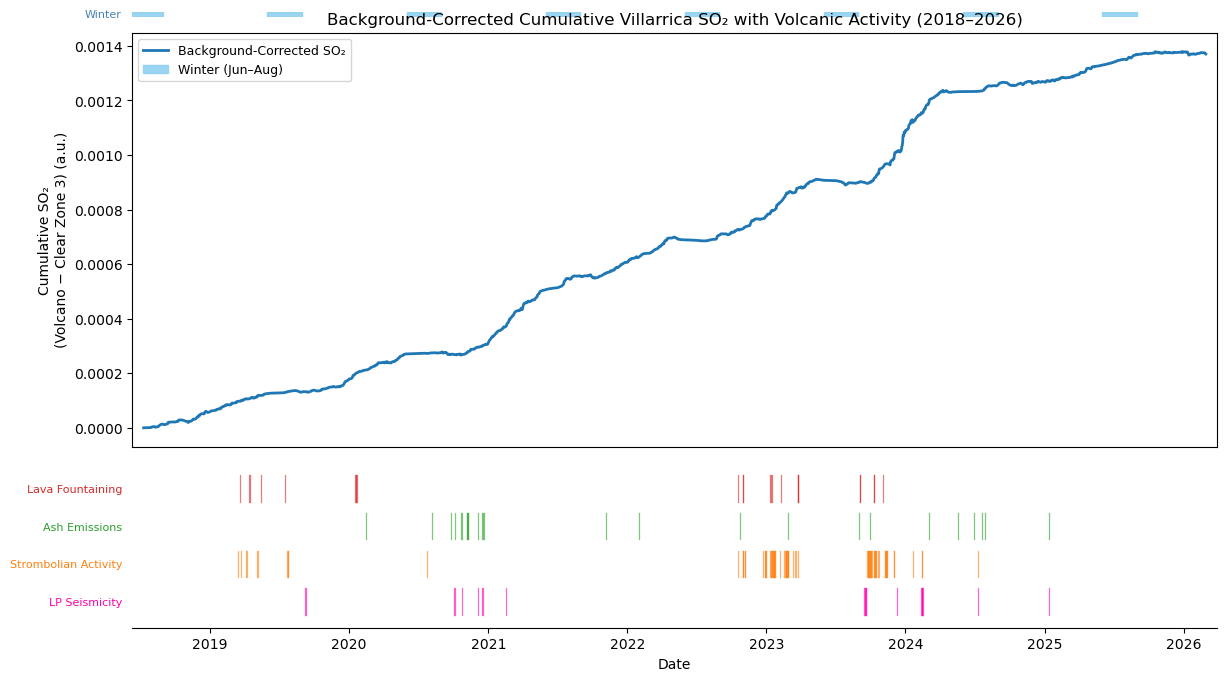

In [113]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

# --- Colour-blind-safe palette ---
SO2_col   = '#1f77b4'
LP_col    = '#FF00AA'
STROM_col = '#ff7f0e'
ASH_col   = '#2ca02c'
FNT_col   = '#d62728'
WINTER_col = '#89CFF0'

# --- Event definitions for activity panel ---
# Each entry: (dates, y_position, colour, label)
event_types = [
    (lp_dt,            1, LP_col,    'LP Seismicity'),
    (strombolian_dt,   2, STROM_col, 'Strombolian Activity'),
    (ash_dt,           3, ASH_col,   'Ash Emissions'),
    (lava_fountain_dt, 4, FNT_col,   'Lava Fountaining'),
]

# --- Create figure: top bar + SO2 panel + activity panel ---
fig = plt.figure(figsize=(14, 8))

# Row heights: [winter bar, SO2 panel, activity panel]
gs = fig.add_gridspec(3, 1, height_ratios=[0.04, 3, 1.2],
                      hspace=0.08)

ax_bar      = fig.add_subplot(gs[0])   # thin winter bar
ax_so2      = fig.add_subplot(gs[1])   # cumulative SO2
ax_activity = fig.add_subplot(gs[2])   # activity lines

# ── Winter bar ──────────────────────────────────────────────────────────────
# Share x-axis limits with SO2 panel after plotting, so set spans in data
# coordinates using broken_barh on a normalised axis
ax_bar.set_xlim(ax_so2.get_xlim())   # will be synced below via sharex

for year in range(2018, 2026):
    start = mdates.date2num(dt.datetime(year, 6, 1))
    end   = mdates.date2num(dt.datetime(year, 8, 31))
    ax_bar.axvspan(mdates.num2date(start), mdates.num2date(end),
                   color=WINTER_col, alpha=0.85)

ax_bar.set_yticks([])
ax_bar.set_xticks([])
for spine in ax_bar.spines.values():
    spine.set_visible(False)
ax_bar.set_facecolor('none')
ax_bar.text(-0.01, 0.5, 'Winter', transform=ax_bar.transAxes,
            ha='right', va='center', fontsize=8, color='steelblue')

# ── Cumulative SO₂ panel ─────────────────────────────────────────────────────
ax_so2.plot(df['date'], df['cumulative_true_volcano'],
            lw=2, color=SO2_col, label='Background-Corrected SO₂')

ax_so2.set_ylabel('Cumulative SO₂\n(Volcano − Clear Zone 3) (a.u.)')
ax_so2.set_title('Background-Corrected Cumulative Villarrica SO₂ with Volcanic Activity (2018–2026)')
ax_so2.tick_params(labelbottom=False)   # hide x tick labels — shared with activity

# ── Activity panel ────────────────────────────────────────────────────────────
y_labels = {}
for dates, y_pos, colour, label in event_types:
    for date in dates:
        ax_activity.plot([date, date], [y_pos - 0.35, y_pos + 0.35],
                         color=colour, lw=0.9, alpha=0.6)
    y_labels[y_pos] = (label, colour)

ax_activity.set_yticks(list(y_labels.keys()))
ax_activity.set_yticklabels(
    [y_labels[k][0] for k in sorted(y_labels.keys())],
    fontsize=8
)
# Colour each y tick label to match its event colour
for tick_label, k in zip(ax_activity.get_yticklabels(), sorted(y_labels.keys())):
    tick_label.set_color(y_labels[k][1])

ax_activity.set_ylim(0.3, 4.7)
ax_activity.set_xlabel('Date')
ax_activity.yaxis.grid(False)
ax_activity.xaxis.grid(False)
for spine in ['top', 'right', 'left']:
    ax_activity.spines[spine].set_visible(False)
ax_activity.tick_params(left=False)

# ── Share x-axis across all three panels ─────────────────────────────────────
# Re-build with sharex so zooming/panning stays in sync
# (Easier to link after the fact via set_xlim + callbacks)
x_min = df['date'].min() - pd.Timedelta(days=30)
x_max = df['date'].max() + pd.Timedelta(days=30)

for ax in [ax_bar, ax_so2, ax_activity]:
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax_bar.set_xticks([])          # bar never shows ticks
ax_so2.set_xticks([])          # SO2 panel hides labels (activity shows them)

# ── SO₂ panel legend ─────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=SO2_col, lw=2, label='Background-Corrected SO₂'),
    mpatches.Patch(color=WINTER_col, alpha=0.85, label='Winter (Jun–Aug)'),
]
ax_so2.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\davie\AppData\Local\Temp\ipykernel_21440\2900805829.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


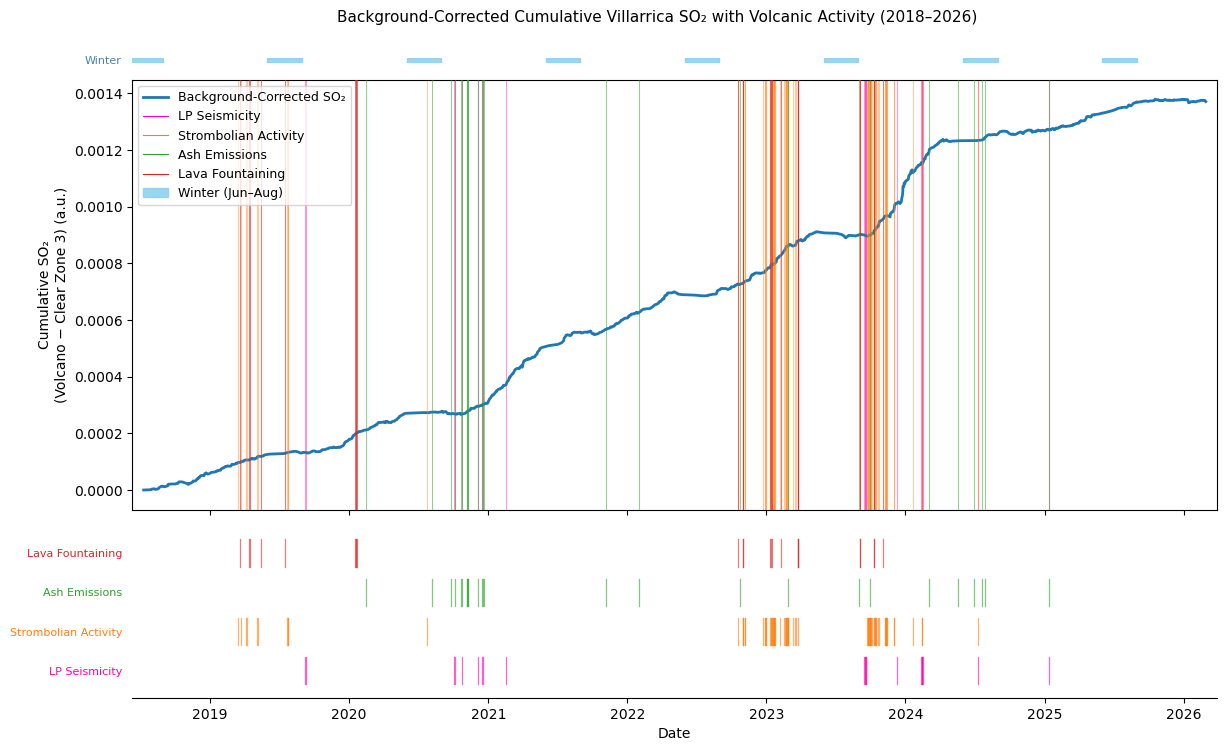

In [114]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

# --- Colours ---
SO2_col    = '#1f77b4'
LP_col     = '#FF00AA'
STROM_col  = '#ff7f0e'
ASH_col    = '#2ca02c'
FNT_col    = '#d62728'
WINTER_col = '#89CFF0'

event_types = [
    (lp_dt,            1, LP_col,    'LP Seismicity'),
    (strombolian_dt,   2, STROM_col, 'Strombolian Activity'),
    (ash_dt,           3, ASH_col,   'Ash Emissions'),
    (lava_fountain_dt, 4, FNT_col,   'Lava Fountaining'),
]

# --- Figure layout ---
# Title lives above ax_bar via suptitle; order from top: bar → SO2 → activity
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(3, 1,
                      height_ratios=[0.04, 3, 1.2],
                      hspace=0.08,
                      top=0.91)       # leave room for suptitle above the bar

ax_bar      = fig.add_subplot(gs[0])
ax_so2      = fig.add_subplot(gs[1])
ax_activity = fig.add_subplot(gs[2])

# ── Shared x limits ───────────────────────────────────────────────────────────
x_min = df['date'].min() - pd.Timedelta(days=30)
x_max = df['date'].max() + pd.Timedelta(days=30)

for ax in [ax_bar, ax_so2, ax_activity]:
    ax.set_xlim(x_min, x_max)

# ── Winter bar (top strip) ────────────────────────────────────────────────────
for year in range(2018, 2026):
    ax_bar.axvspan(dt.datetime(year, 6, 1), dt.datetime(year, 8, 31),
                   color=WINTER_col, alpha=0.85)

ax_bar.set_yticks([])
ax_bar.set_xticks([])
for spine in ax_bar.spines.values():
    spine.set_visible(False)
ax_bar.set_facecolor('none')
ax_bar.text(-0.01, 0.5, 'Winter', transform=ax_bar.transAxes,
            ha='right', va='center', fontsize=8, color='steelblue')

# ── Cumulative SO₂ panel ──────────────────────────────────────────────────────
ax_so2.plot(df['date'], df['cumulative_true_volcano'],
            lw=2, color=SO2_col, label='Background-Corrected SO₂')

# Vertical event lines in the SO2 panel
for date in lp_dt:
    ax_so2.axvline(date, color=LP_col,    alpha=0.4, lw=0.8, zorder=1)
for date in strombolian_dt:
    ax_so2.axvline(date, color=STROM_col, alpha=0.4, lw=0.8, zorder=2)
for date in ash_dt:
    ax_so2.axvline(date, color=ASH_col,   alpha=0.5, lw=0.8, zorder=3)
for date in lava_fountain_dt:
    ax_so2.axvline(date, color=FNT_col,   alpha=0.6, lw=0.8, zorder=4)

ax_so2.set_ylabel('Cumulative SO₂\n(Volcano − Clear Zone 3) (a.u.)')
ax_so2.tick_params(labelbottom=False)
ax_so2.xaxis.set_major_locator(mdates.YearLocator())

# ── Activity panel ────────────────────────────────────────────────────────────
y_labels = {}
for dates, y_pos, colour, label in event_types:
    for date in dates:
        ax_activity.plot([date, date], [y_pos - 0.35, y_pos + 0.35],
                         color=colour, lw=0.9, alpha=0.6)
    y_labels[y_pos] = (label, colour)

ax_activity.set_yticks(list(y_labels.keys()))
ax_activity.set_yticklabels(
    [y_labels[k][0] for k in sorted(y_labels.keys())], fontsize=8)
for tick_label, k in zip(ax_activity.get_yticklabels(), sorted(y_labels.keys())):
    tick_label.set_color(y_labels[k][1])

ax_activity.set_ylim(0.3, 4.7)
ax_activity.set_xlabel('Date')
ax_activity.xaxis.set_major_locator(mdates.YearLocator())
ax_activity.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
for spine in ['top', 'right', 'left']:
    ax_activity.spines[spine].set_visible(False)
ax_activity.tick_params(left=False)

# ── Title above everything (above the bar) ────────────────────────────────────
fig.suptitle('Background-Corrected Cumulative Villarrica SO₂ with Volcanic Activity (2018–2026)',
             fontsize=11, y=0.97)

# ── Legend on SO₂ panel ───────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=SO2_col,    lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=LP_col,     lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col,  lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,    lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,    lw=0.8, label='Lava Fountaining'),
    mpatches.Patch(color=WINTER_col, alpha=0.85, label='Winter (Jun–Aug)'),
]
ax_so2.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\davie\AppData\Local\Temp\ipykernel_21440\2087550341.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


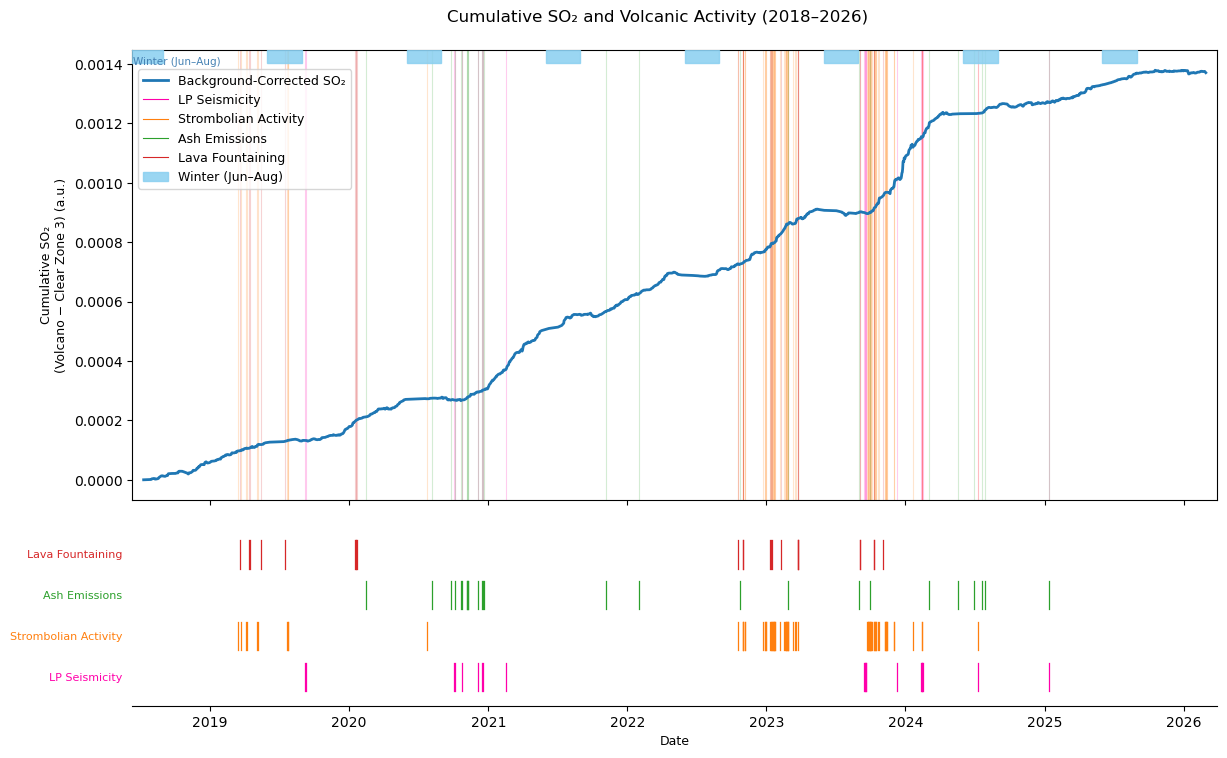

In [115]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

# --- Colours ---
SO2_col    = '#1f77b4'
LP_col     = '#FF00AA'
STROM_col  = '#ff7f0e'
ASH_col    = '#2ca02c'
FNT_col    = '#d62728'
WINTER_col = '#89CFF0'

event_types = [
    (lp_dt,            1, LP_col,    'LP Seismicity'),
    (strombolian_dt,   2, STROM_col, 'Strombolian Activity'),
    (ash_dt,           3, ASH_col,   'Ash Emissions'),
    (lava_fountain_dt, 4, FNT_col,   'Lava Fountaining'),
]

# --- Figure layout: just two panels now, no separate bar axis ---
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 1,
                      height_ratios=[3, 1.2],
                      hspace=0.08,
                      top=0.93)

ax_so2      = fig.add_subplot(gs[0])
ax_activity = fig.add_subplot(gs[1])

# ── Shared x limits ───────────────────────────────────────────────────────────
x_min = df['date'].min() - pd.Timedelta(days=30)
x_max = df['date'].max() + pd.Timedelta(days=30)

for ax in [ax_so2, ax_activity]:
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Cumulative SO₂ panel ──────────────────────────────────────────────────────
ax_so2.plot(df['date'], df['cumulative_true_volcano'],
            lw=2, color=SO2_col, zorder=3)

# Vertical event lines
for date in lp_dt:
    ax_so2.axvline(date, color=LP_col,    alpha=0.2, lw=0.8, zorder=2)
for date in strombolian_dt:
    ax_so2.axvline(date, color=STROM_col, alpha=0.2, lw=0.8, zorder=2)
for date in ash_dt:
    ax_so2.axvline(date, color=ASH_col,   alpha=0.2, lw=0.8, zorder=2)
for date in lava_fountain_dt:
    ax_so2.axvline(date, color=FNT_col,   alpha=0.2, lw=0.8, zorder=2)

ax_so2.set_ylabel('Cumulative SO₂\n(Volcano − Clear Zone 3) (a.u.)', fontsize=9)
ax_so2.tick_params(labelbottom=False)

# ── Winter strip pinned inside the top of ax_so2 ─────────────────────────────
# Use a blended transform: x in data coords, y in axes coords (0=bottom, 1=top)
# The strip occupies the top 3% of the axes height
from matplotlib.transforms import blended_transform_factory

trans = blended_transform_factory(ax_so2.transData, ax_so2.transAxes)

for year in range(2018, 2026):
    start = dt.datetime(year, 6, 1)
    end   = dt.datetime(year, 8, 31)
    rect  = mpatches.Rectangle(
        (mdates.date2num(start), 0.97),   # (x in data, y in axes) — top 3%
        mdates.date2num(end) - mdates.date2num(start),
        0.03,                              # height in axes fraction
        transform=trans,
        color=WINTER_col, alpha=0.85,
        zorder=5, clip_on=True
    )
    ax_so2.add_patch(rect)

# 'Winter' label just inside the top-left of the SO2 panel
ax_so2.text(0.001, 0.985, 'Winter (Jun–Aug)',
            transform=ax_so2.transAxes,
            ha='left', va='top', fontsize=7.5, color='steelblue',
            zorder=6)

# ── Activity panel ────────────────────────────────────────────────────────────
y_labels = {}
for dates, y_pos, colour, label in event_types:
    for date in dates:
        ax_activity.plot([date, date], [y_pos - 0.35, y_pos + 0.35],
                         color=colour, lw=0.9, alpha=1)
    y_labels[y_pos] = (label, colour)

ax_activity.set_yticks(list(y_labels.keys()))
ax_activity.set_yticklabels(
    [y_labels[k][0] for k in sorted(y_labels.keys())], fontsize=8)
for tick_label, k in zip(ax_activity.get_yticklabels(), sorted(y_labels.keys())):
    tick_label.set_color(y_labels[k][1])

ax_activity.set_ylim(0.3, 4.7)
ax_activity.set_xlabel('Date', fontsize=9)
for spine in ['top', 'right', 'left']:
    ax_activity.spines[spine].set_visible(False)
ax_activity.tick_params(left=False)

# ── Title ─────────────────────────────────────────────────────────────────────
fig.suptitle(
    'Cumulative SO₂ and Volcanic Activity (2018–2026)',
    fontsize=12, y=0.98)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=SO2_col,    lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=LP_col,     lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col,  lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,    lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,    lw=0.8, label='Lava Fountaining'),
    mpatches.Patch(color=WINTER_col, alpha=0.85, label='Winter (Jun–Aug)'),
]
ax_so2.legend(handles=legend_elements, loc='upper left', fontsize=9,
              bbox_to_anchor=(0, 0.97))   # nudge legend below the winter strip

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("newcumulative.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\davie\AppData\Local\Temp\ipykernel_21440\4172280115.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


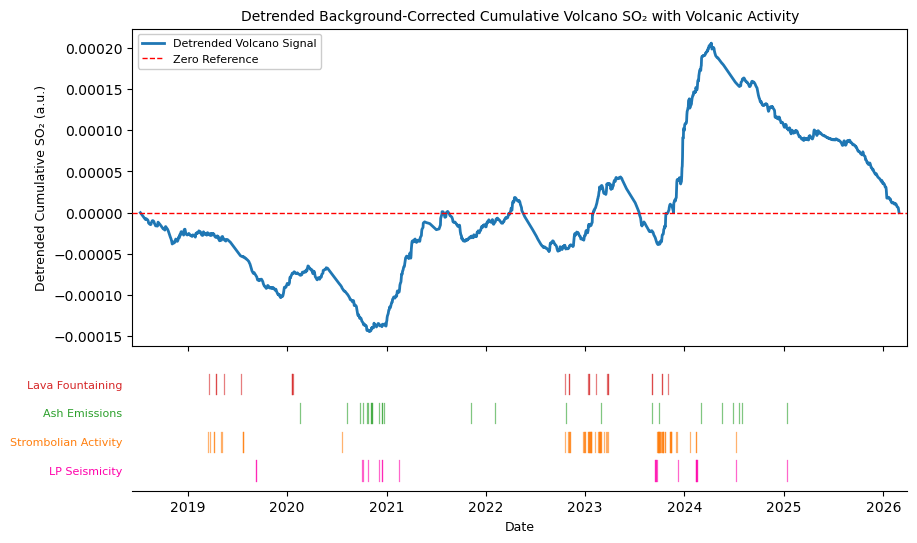

In [116]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Convert dates to matplotlib numeric format ---
dates_num = mdates.date2num(df['date'])

# --- Linear trend from start to end ---
start_val = df['cumulative_true_volcano'].iloc[0]
end_val   = df['cumulative_true_volcano'].iloc[-1]

linear_trend = start_val + (end_val - start_val) * (
    (dates_num - dates_num[0]) / (dates_num[-1] - dates_num[0])
)

df['detrended_true_volcano'] = df['cumulative_true_volcano'] - linear_trend

# --- Event definitions ---
event_types = [
    (lp_dt,            1, LP_col,    'LP Seismicity'),
    (strombolian_dt,   2, STROM_col, 'Strombolian Activity'),
    (ash_dt,           3, ASH_col,   'Ash Emissions'),
    (lava_fountain_dt, 4, FNT_col,   'Lava Fountaining'),
]

# --- Figure layout ---
fig = plt.figure(figsize=(10, 6))
gs  = fig.add_gridspec(2, 1, height_ratios=[3, 1.2], hspace=0.08)

ax_det      = fig.add_subplot(gs[0])
ax_activity = fig.add_subplot(gs[1])

# ── Shared x limits ───────────────────────────────────────────────────────────
x_min = df['date'].min() - pd.Timedelta(days=30)
x_max = df['date'].max() + pd.Timedelta(days=30)

for ax in [ax_det, ax_activity]:
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

# ── Detrended SO₂ panel ───────────────────────────────────────────────────────
ax_det.plot(df['date'], df['detrended_true_volcano'],
            lw=2, color=SO2_col, label='Detrended Volcano Signal', zorder=3)
ax_det.axhline(0, color='r', linestyle='--', lw=1, zorder=3, label='Zero Reference')

ax_det.set_ylabel('Detrended Cumulative SO₂ (a.u.)', fontsize=9)
ax_det.set_title(
    'Detrended Background-Corrected Cumulative Volcano SO₂ with Volcanic Activity',
    fontsize=10)
ax_det.tick_params(labelbottom=False)
ax_det.legend(loc='best', fontsize=8, framealpha=1)

# ── Activity panel ────────────────────────────────────────────────────────────
y_labels = {}
for dates, y_pos, colour, label in event_types:
    for date in dates:
        ax_activity.plot([date, date], [y_pos - 0.35, y_pos + 0.35],
                         color=colour, lw=0.9, alpha=0.6)
    y_labels[y_pos] = (label, colour)

ax_activity.set_yticks(sorted(y_labels.keys()))
ax_activity.set_yticklabels(
    [y_labels[k][0] for k in sorted(y_labels.keys())], fontsize=8)
for tick_label, k in zip(ax_activity.get_yticklabels(), sorted(y_labels.keys())):
    tick_label.set_color(y_labels[k][1])

ax_activity.set_ylim(0.3, 4.7)
ax_activity.set_xlabel('Date', fontsize=9)
for spine in ['top', 'right', 'left']:
    ax_activity.spines[spine].set_visible(False)
ax_activity.tick_params(left=False)

plt.tight_layout()
plt.savefig("figuredetrended.png", dpi=800, bbox_inches='tight')
plt.show()

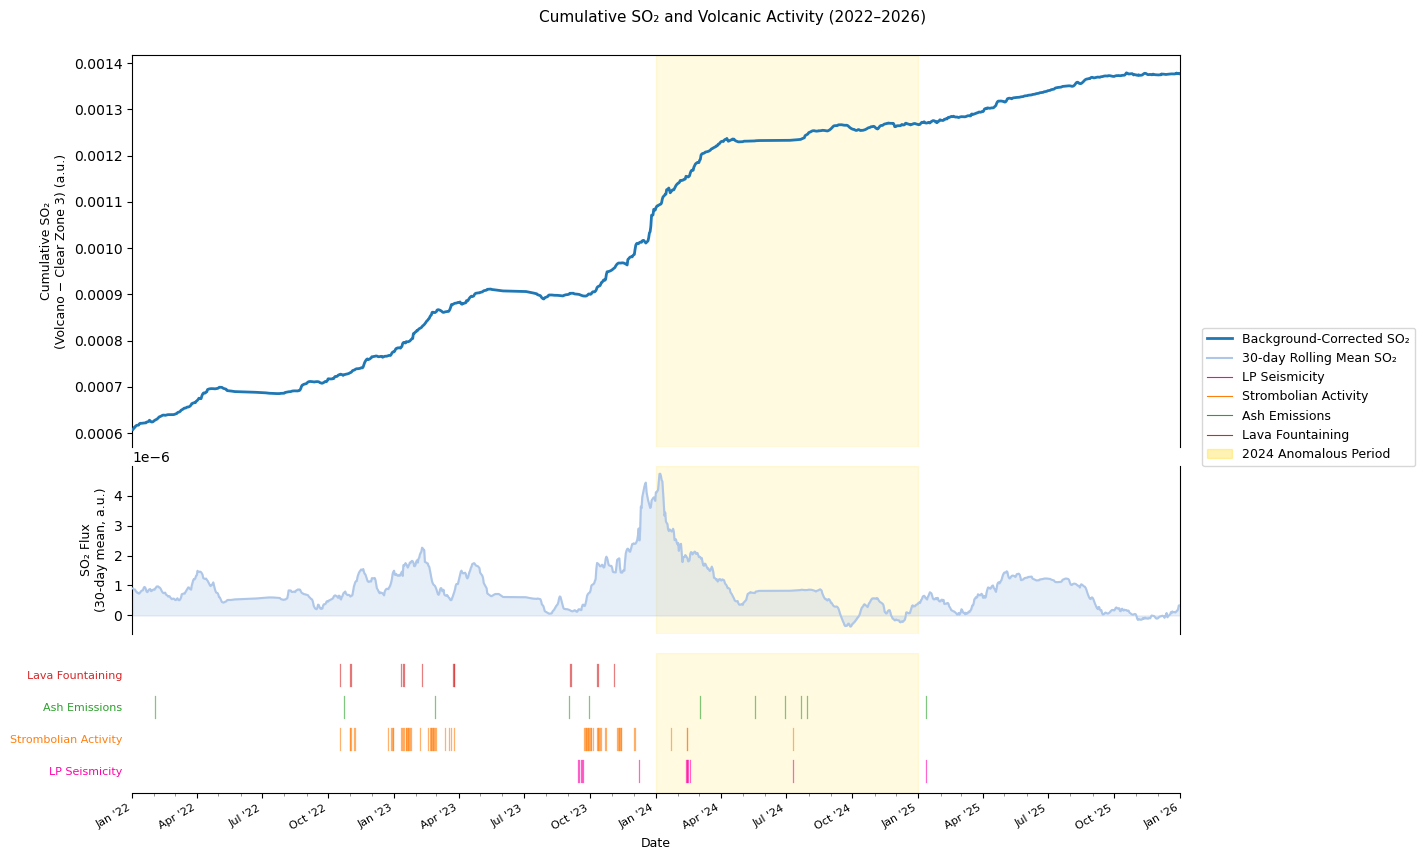

In [117]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

# --- 30-day rolling mean of daily flux (rate of change proxy) ---
df['rolling_so2'] = df['volcano'].rolling(window=30, min_periods=5, center=True).mean()

# --- Filter to 2022–2026 window ---
df_2 = df[(df['date'] >= '2022-01-01') & (df['date'] <= '2026-01-01')].copy()

# --- Filter event dates to window ---
def filter_dates(dates, start, end):
    return [d for d in dates if pd.Timestamp(start) <= d <= pd.Timestamp(end)]

strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

w_start, w_end = '2022-01-01', '2026-01-01'
lp_w    = filter_dates(lp_dt,            w_start, w_end)
strom_w = filter_dates(strombolian_dt,   w_start, w_end)
ash_w   = filter_dates(ash_dt,           w_start, w_end)
fnt_w   = filter_dates(lava_fountain_dt, w_start, w_end)

# --- Colours ---
SO2_col   = '#1f77b4'
ROLL_col  = '#aec7e8'
LP_col    = '#FF00AA'
STROM_col = '#ff7f0e'
ASH_col   = '#2ca02c'
FNT_col   = '#d62728'

event_types = [
    (lp_w,    1, LP_col,    'LP Seismicity'),
    (strom_w, 2, STROM_col, 'Strombolian Activity'),
    (ash_w,   3, ASH_col,   'Ash Emissions'),
    (fnt_w,   4, FNT_col,   'Lava Fountaining'),
]

# --- Figure layout: cumulative | rolling mean | activity ---
fig = plt.figure(figsize=(16, 9))
gs  = fig.add_gridspec(3, 1,
                       height_ratios=[2.8, 1.2, 1.0],
                       hspace=0.08,
                       top=0.93,
                       right=0.78)

ax_cum      = fig.add_subplot(gs[0])
ax_roll     = fig.add_subplot(gs[1])
ax_activity = fig.add_subplot(gs[2])

# ── Shared x limits ───────────────────────────────────────────────────────────
x_min = pd.Timestamp('2022-01-01')
x_max = pd.Timestamp('2026-01-01')

for ax in [ax_cum, ax_roll, ax_activity]:
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))  # quarterly
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())                        # monthly minor
    ax.tick_params(axis='x', which='minor', length=2, color='grey')

# ── Cumulative SO₂ panel ──────────────────────────────────────────────────────
ax_cum.plot(df_2['date'], df_2['cumulative_true_volcano'],
            lw=2, color=SO2_col, zorder=3)

ax_cum.set_ylabel('Cumulative SO₂\n(Volcano − Clear Zone 3) (a.u.)', fontsize=9)
ax_cum.tick_params(labelbottom=False)
ax_cum.spines['bottom'].set_visible(False)
ax_cum.tick_params(axis='x', which='both', bottom=False)

# Annotate the 2024 anomaly period with a subtle shaded band
ax_cum.axvspan(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'),
               color='gold', alpha=0.12, zorder=0, label='2024 Anomalous Period')
ax_roll.axvspan(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'),
                color='gold', alpha=0.12, zorder=0)
ax_activity.axvspan(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'),
                    color='gold', alpha=0.12, zorder=0)

# ── 30-day rolling mean panel ─────────────────────────────────────────────────
ax_roll.plot(df_2['date'], df_2['rolling_so2'],
             lw=1.5, color=ROLL_col, zorder=3)
ax_roll.fill_between(df_2['date'], df_2['rolling_so2'],
                     alpha=0.3, color=ROLL_col, zorder=2)
ax_roll.set_ylabel('SO₂ Flux\n(30-day mean, a.u.)', fontsize=9)
ax_roll.tick_params(labelbottom=False)
ax_roll.spines['top'].set_visible(False)
ax_roll.spines['bottom'].set_visible(False)
ax_roll.tick_params(axis='x', which='both', bottom=False)

# ── Activity panel ────────────────────────────────────────────────────────────
y_labels = {}
for dates, y_pos, colour, label in event_types:
    for date in dates:
        ax_activity.plot([date, date], [y_pos - 0.35, y_pos + 0.35],
                         color=colour, lw=0.9, alpha=0.6)
    y_labels[y_pos] = (label, colour)

ax_activity.set_yticks(sorted(y_labels.keys()))
ax_activity.set_yticklabels(
    [y_labels[k][0] for k in sorted(y_labels.keys())], fontsize=8)
for tick_label, k in zip(ax_activity.get_yticklabels(), sorted(y_labels.keys())):
    tick_label.set_color(y_labels[k][1])

ax_activity.set_ylim(0.3, 4.7)
ax_activity.set_xlabel('Date', fontsize=9)
plt.setp(ax_activity.get_xticklabels(), rotation=30, ha='right', fontsize=8)
for spine in ['top', 'right', 'left']:
    ax_activity.spines[spine].set_visible(False)
ax_activity.tick_params(left=False)

# ── Title ─────────────────────────────────────────────────────────────────────
fig.suptitle('Cumulative SO₂ and Volcanic Activity (2022–2026)',
             fontsize=11, y=0.98)

# ── Legend outside to the right ───────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=SO2_col,   lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=ROLL_col,  lw=1.5, label='30-day Rolling Mean SO₂'),
    Line2D([0], [0], color=LP_col,    lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col, lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,   lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,   lw=0.8, label='Lava Fountaining'),
    mpatches.Patch(color='gold',      alpha=0.3, label='2024 Anomalous Period'),
]

fig.legend(handles=legend_elements,
           loc='center left',
           bbox_to_anchor=(0.79, 0.55),
           fontsize=9,
           framealpha=0.9,
           edgecolor='lightgrey')

plt.savefig("zoomed_2022_2026.png", dpi=800, bbox_inches='tight')
plt.show()

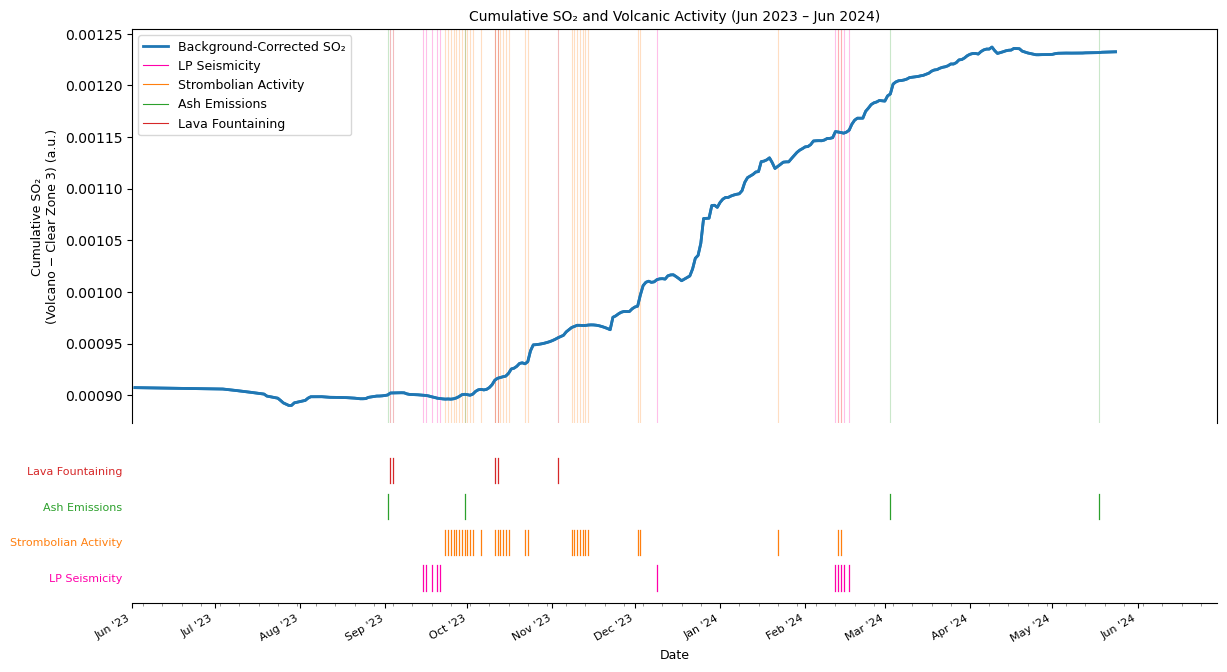

In [121]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

# --- Filter to window ---
w_start = '2023-06-01'
w_end   = '2024-06-01'

df_w = df[(df['date'] >= w_start) & (df['date'] <= w_end)].copy()

# --- Filter event dates to window ---
strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

def filter_dates(dates, start, end):
    return [d for d in dates if pd.Timestamp(start) <= d <= pd.Timestamp(end)]

lp_w    = filter_dates(lp_dt,            w_start, w_end)
strom_w = filter_dates(strombolian_dt,   w_start, w_end)
ash_w   = filter_dates(ash_dt,           w_start, w_end)
fnt_w   = filter_dates(lava_fountain_dt, w_start, w_end)

# --- Colours ---
SO2_col   = '#1f77b4'
LP_col    = '#FF00AA'
STROM_col = '#ff7f0e'
ASH_col   = '#2ca02c'
FNT_col   = '#d62728'

event_types = [
    (lp_w,    1, LP_col,    'LP Seismicity'),
    (strom_w, 2, STROM_col, 'Strombolian Activity'),
    (ash_w,   3, ASH_col,   'Ash Emissions'),
    (fnt_w,   4, FNT_col,   'Lava Fountaining'),
]

# --- Figure layout ---
fig = plt.figure(figsize=(14, 7))
gs  = fig.add_gridspec(2, 1,
                       height_ratios=[3, 1.2],
                       hspace=0.08,
                       top=0.93,)

ax_cum      = fig.add_subplot(gs[0])
ax_activity = fig.add_subplot(gs[1])

# ── Shared x limits ───────────────────────────────────────────────────────────
x_min = pd.Timestamp(w_start)
x_max = pd.Timestamp(w_end)

for ax in [ax_cum, ax_activity]:
   for ax in [ax_cum, ax_activity]:
    ax.set_xlim(pd.Timestamp(w_start), pd.Timestamp('2024-06-30'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))
    ax.tick_params(axis='x', which='minor', length=2, color='grey')

# ── Cumulative SO₂ panel ──────────────────────────────────────────────────────

# Event lines first (zorder=1) so curve sits on top (zorder=3)
for date in lp_w:
    ax_cum.axvline(date, color=LP_col,    alpha=0.25, lw=0.8, zorder=1)
for date in strom_w:
    ax_cum.axvline(date, color=STROM_col, alpha=0.25, lw=0.8, zorder=1)
for date in ash_w:
    ax_cum.axvline(date, color=ASH_col,   alpha=0.25, lw=0.8, zorder=1)
for date in fnt_w:
    ax_cum.axvline(date, color=FNT_col,   alpha=0.30, lw=0.8, zorder=1)

ax_cum.plot(df_w['date'], df_w['cumulative_true_volcano'],
            lw=2, color=SO2_col, zorder=3)

# ── Cumulative SO₂ panel ──────────────────────────────────────────────────────
ax_cum.plot(df_w['date'], df_w['cumulative_true_volcano'],
            lw=2, color=SO2_col, zorder=3)

ax_cum.set_ylabel('Cumulative SO₂\n(Volcano − Clear Zone 3) (a.u.)', fontsize=9)
ax_cum.set_title('Cumulative SO₂ and Volcanic Activity (Jun 2023 – Jun 2024)',
                 fontsize=10)
ax_cum.tick_params(labelbottom=False)
ax_cum.spines['bottom'].set_visible(False)
ax_cum.tick_params(axis='x', which='both', bottom=False)

# ── Activity panel ────────────────────────────────────────────────────────────
y_labels = {}
for dates, y_pos, colour, label in event_types:
    for date in dates:
        ax_activity.plot([date, date], [y_pos - 0.35, y_pos + 0.35],
                         color=colour, lw=0.9, alpha=1)
    y_labels[y_pos] = (label, colour)

ax_activity.set_yticks(sorted(y_labels.keys()))
ax_activity.set_yticklabels(
    [y_labels[k][0] for k in sorted(y_labels.keys())], fontsize=8)
for tick_label, k in zip(ax_activity.get_yticklabels(), sorted(y_labels.keys())):
    tick_label.set_color(y_labels[k][1])

ax_activity.set_ylim(0.3, 4.7)
ax_activity.set_xlabel('Date', fontsize=9)
plt.setp(ax_activity.get_xticklabels(), rotation=30, ha='right', fontsize=8)
for spine in ['top', 'right', 'left']:
    ax_activity.spines[spine].set_visible(False)
ax_activity.tick_params(left=False)

# ── Legend outside to the right ───────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=SO2_col,   lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=LP_col,    lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col, lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,   lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,   lw=0.8, label='Lava Fountaining'),
]

ax_cum.legend(handles=legend_elements,
           loc='upper left',
           fontsize=9,
           framealpha=0.9,
           edgecolor='lightgrey')

plt.savefig("zoomed_2023_2024.png", dpi=400, bbox_inches='tight')
plt.show()

C:\Users\davie\AppData\Local\Temp\ipykernel_21440\3504074282.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


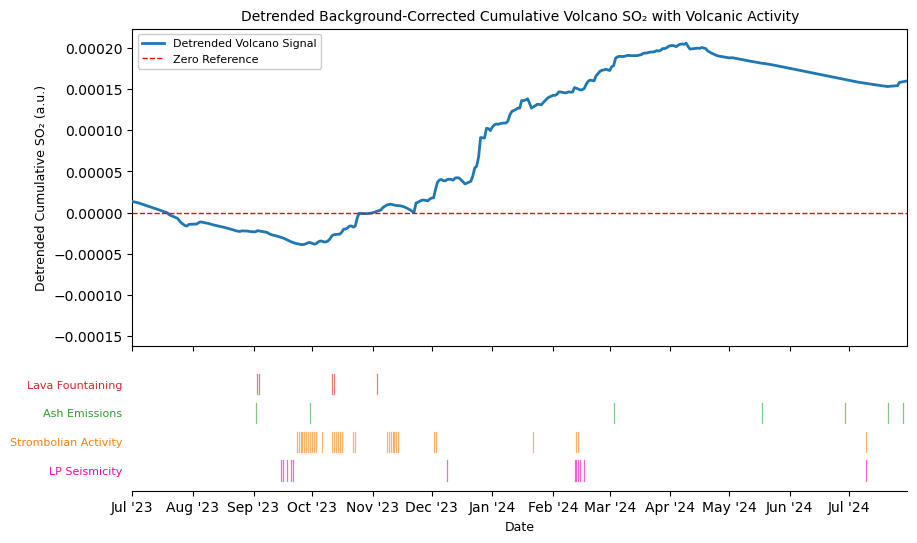

In [80]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Convert dates to matplotlib numeric format ---
dates_num = mdates.date2num(df['date'])

# --- Linear trend from start to end ---
start_val = df['cumulative_true_volcano'].iloc[0]
end_val   = df['cumulative_true_volcano'].iloc[-1]

linear_trend = start_val + (end_val - start_val) * (
    (dates_num - dates_num[0]) / (dates_num[-1] - dates_num[0])
)

df['detrended_true_volcano'] = df['cumulative_true_volcano'] - linear_trend

# --- Event definitions ---
event_types = [
    (lp_dt,            1, LP_col,    'LP Seismicity'),
    (strombolian_dt,   2, STROM_col, 'Strombolian Activity'),
    (ash_dt,           3, ASH_col,   'Ash Emissions'),
    (lava_fountain_dt, 4, FNT_col,   'Lava Fountaining'),
]

# --- Figure layout ---
fig = plt.figure(figsize=(10, 6))
gs  = fig.add_gridspec(2, 1, height_ratios=[3, 1.2], hspace=0.08)

ax_det      = fig.add_subplot(gs[0])
ax_activity = fig.add_subplot(gs[1])

# ── Shared x limits ───────────────────────────────────────────────────────────
x_min = pd.Timestamp('2023-07-01')
x_max = pd.Timestamp('2024-07-31')

for ax in [ax_det, ax_activity]:
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

# and at the bottom:
plt.savefig("figuredetrended.png", dpi=150, bbox_inches='tight')

# ── Detrended SO₂ panel ───────────────────────────────────────────────────────
ax_det.plot(df['date'], df['detrended_true_volcano'],
            lw=2, color=SO2_col, label='Detrended Volcano Signal', zorder=3)
ax_det.axhline(0, color='r', linestyle='--', lw=1, zorder=3, label='Zero Reference')

ax_det.set_ylabel('Detrended Cumulative SO₂ (a.u.)', fontsize=9)
ax_det.set_title(
    'Detrended Background-Corrected Cumulative Volcano SO₂ with Volcanic Activity',
    fontsize=10)
ax_det.tick_params(labelbottom=False)
ax_det.legend(loc='best', fontsize=8, framealpha=1)

# ── Activity panel ────────────────────────────────────────────────────────────
y_labels = {}
for dates, y_pos, colour, label in event_types:
    for date in dates:
        ax_activity.plot([date, date], [y_pos - 0.35, y_pos + 0.35],
                         color=colour, lw=0.9, alpha=0.6)
    y_labels[y_pos] = (label, colour)

ax_activity.set_yticks(sorted(y_labels.keys()))
ax_activity.set_yticklabels(
    [y_labels[k][0] for k in sorted(y_labels.keys())], fontsize=8)
for tick_label, k in zip(ax_activity.get_yticklabels(), sorted(y_labels.keys())):
    tick_label.set_color(y_labels[k][1])

ax_activity.set_ylim(0.3, 4.7)
ax_activity.set_xlabel('Date', fontsize=9)
for spine in ['top', 'right', 'left']:
    ax_activity.spines[spine].set_visible(False)
ax_activity.tick_params(left=False)

plt.tight_layout()
plt.savefig("figuredetrended20232024.png", dpi=800, bbox_inches='tight')
plt.show()

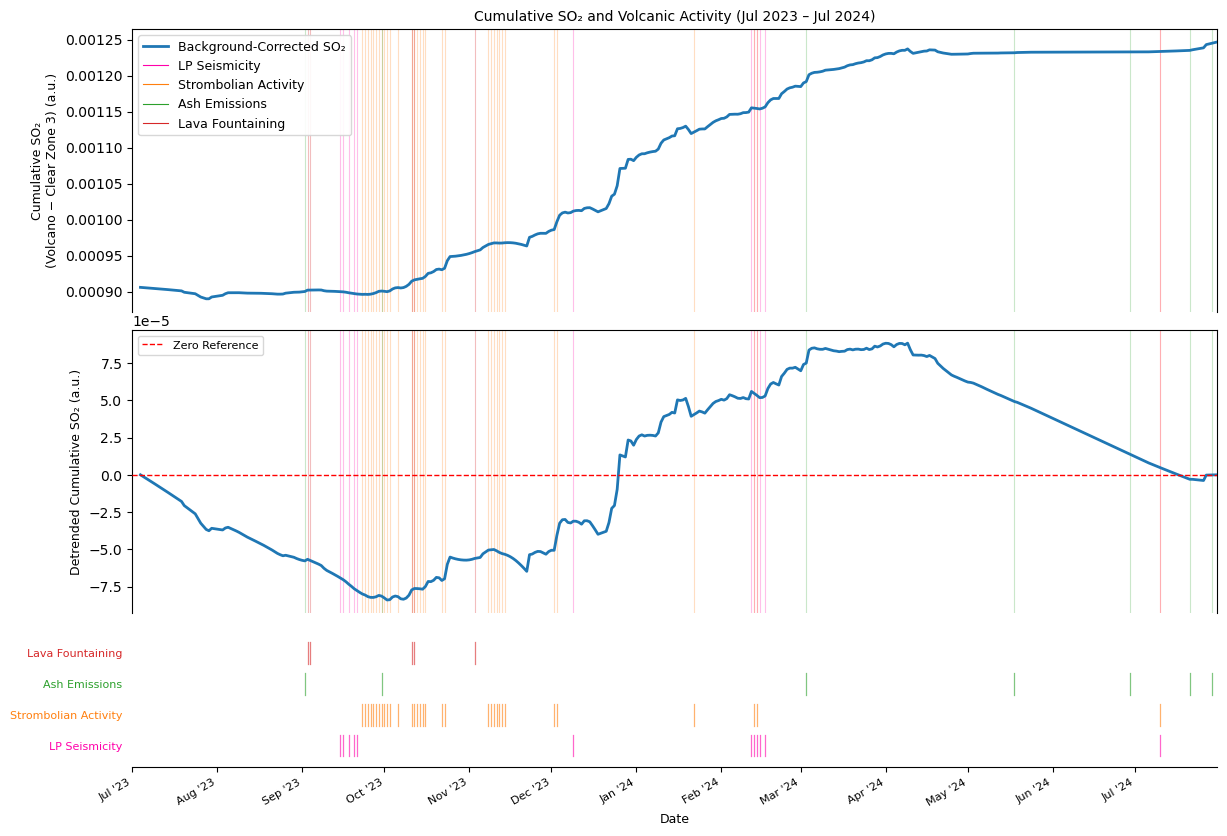

In [82]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['figure.dpi'] = 100

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

# --- Detrend on full dataset before filtering ---
dates_num = mdates.date2num(df['date'])
start_val = df['cumulative_true_volcano'].iloc[0]
end_val   = df['cumulative_true_volcano'].iloc[-1]

linear_trend = start_val + (end_val - start_val) * (
    (dates_num - dates_num[0]) / (dates_num[-1] - dates_num[0])
)
df['detrended_true_volcano'] = df['cumulative_true_volcano'] - linear_trend

# --- Filter to window ---
w_start = '2023-07-01'
w_end   = '2024-07-31'
df_w = df[(df['date'] >= w_start) & (df['date'] <= w_end)].copy()

dates_num_w = mdates.date2num(df_w['date'])
start_val_w = df_w['cumulative_true_volcano'].iloc[0]
end_val_w   = df_w['cumulative_true_volcano'].iloc[-1]

linear_trend_w = start_val_w + (end_val_w - start_val_w) * (
    (dates_num_w - dates_num_w[0]) / (dates_num_w[-1] - dates_num_w[0])
)
df_w['detrended_true_volcano'] = df_w['cumulative_true_volcano'] - linear_trend_w

# --- Filter event dates to window ---
strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

def filter_dates(dates, start, end):
    return [d for d in dates if pd.Timestamp(start) <= d <= pd.Timestamp(end)]

lp_w    = filter_dates(lp_dt,            w_start, w_end)
strom_w = filter_dates(strombolian_dt,   w_start, w_end)
ash_w   = filter_dates(ash_dt,           w_start, w_end)
fnt_w   = filter_dates(lava_fountain_dt, w_start, w_end)

# --- Colours ---
SO2_col   = '#1f77b4'
LP_col    = '#FF00AA'
STROM_col = '#ff7f0e'
ASH_col   = '#2ca02c'
FNT_col   = '#d62728'

event_types = [
    (lp_w,    1, LP_col,    'LP Seismicity'),
    (strom_w, 2, STROM_col, 'Strombolian Activity'),
    (ash_w,   3, ASH_col,   'Ash Emissions'),
    (fnt_w,   4, FNT_col,   'Lava Fountaining'),
]

# --- Figure layout: cumulative | detrended | activity ---
fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(3, 1,
                       height_ratios=[2.5, 2.5, 1.2],
                       hspace=0.08,
                       top=0.93)

ax_cum      = fig.add_subplot(gs[0])
ax_det      = fig.add_subplot(gs[1])
ax_activity = fig.add_subplot(gs[2])

# ── Shared x limits ───────────────────────────────────────────────────────────
x_min = pd.Timestamp(w_start)
x_max = pd.Timestamp(w_end)

for ax in [ax_cum, ax_det, ax_activity]:
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

# ── Cumulative SO₂ panel ──────────────────────────────────────────────────────
for date in lp_w:
    ax_cum.axvline(date, color=LP_col,    alpha=0.25, lw=0.8, zorder=1)
for date in strom_w:
    ax_cum.axvline(date, color=STROM_col, alpha=0.25, lw=0.8, zorder=1)
for date in ash_w:
    ax_cum.axvline(date, color=ASH_col,   alpha=0.25, lw=0.8, zorder=1)
for date in fnt_w:
    ax_cum.axvline(date, color=FNT_col,   alpha=0.30, lw=0.8, zorder=1)

ax_cum.plot(df_w['date'], df_w['cumulative_true_volcano'],
            lw=2, color=SO2_col, zorder=3)

ax_cum.set_ylabel('Cumulative SO₂\n(Volcano − Clear Zone 3) (a.u.)', fontsize=9)
ax_cum.set_title('Cumulative SO₂ and Volcanic Activity (Jul 2023 – Jul 2024)',
                 fontsize=10)
ax_cum.tick_params(labelbottom=False)
ax_cum.spines['bottom'].set_visible(False)
ax_cum.tick_params(axis='x', which='both', bottom=False)

legend_elements = [
    Line2D([0], [0], color=SO2_col,   lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=LP_col,    lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col, lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,   lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,   lw=0.8, label='Lava Fountaining'),
]
ax_cum.legend(handles=legend_elements, loc='upper left', fontsize=9,
              framealpha=0.9, edgecolor='lightgrey')

# ── Detrended SO₂ panel ───────────────────────────────────────────────────────
for date in lp_w:
    ax_det.axvline(date, color=LP_col,    alpha=0.25, lw=0.8, zorder=1)
for date in strom_w:
    ax_det.axvline(date, color=STROM_col, alpha=0.25, lw=0.8, zorder=1)
for date in ash_w:
    ax_det.axvline(date, color=ASH_col,   alpha=0.25, lw=0.8, zorder=1)
for date in fnt_w:
    ax_det.axvline(date, color=FNT_col,   alpha=0.30, lw=0.8, zorder=1)

ax_det.plot(df_w['date'], df_w['detrended_true_volcano'],
            lw=2, color=SO2_col, zorder=3)
ax_det.axhline(0, color='r', linestyle='--', lw=1, zorder=3,
               label='Zero Reference')

ax_det.set_ylabel('Detrended Cumulative SO₂ (a.u.)', fontsize=9)
ax_det.tick_params(labelbottom=False)
ax_det.spines['bottom'].set_visible(False)
ax_det.tick_params(axis='x', which='both', bottom=False)
ax_det.legend(loc='upper left', fontsize=8, framealpha=0.9, edgecolor='lightgrey')

# ── Activity panel ────────────────────────────────────────────────────────────
y_labels = {}
for dates, y_pos, colour, label in event_types:
    for date in dates:
        ax_activity.plot([date, date], [y_pos - 0.35, y_pos + 0.35],
                         color=colour, lw=0.9, alpha=0.6)
    y_labels[y_pos] = (label, colour)

ax_activity.set_yticks(sorted(y_labels.keys()))
ax_activity.set_yticklabels(
    [y_labels[k][0] for k in sorted(y_labels.keys())], fontsize=8)
for tick_label, k in zip(ax_activity.get_yticklabels(), sorted(y_labels.keys())):
    tick_label.set_color(y_labels[k][1])

ax_activity.set_ylim(0.3, 4.7)
ax_activity.set_xlabel('Date', fontsize=9)
plt.setp(ax_activity.get_xticklabels(), rotation=30, ha='right', fontsize=8)
for spine in ['top', 'right', 'left']:
    ax_activity.spines[spine].set_visible(False)
ax_activity.tick_params(left=False)

plt.savefig("zoomed_2023_2024_detrended.png", dpi=150, bbox_inches='tight')
plt.show()

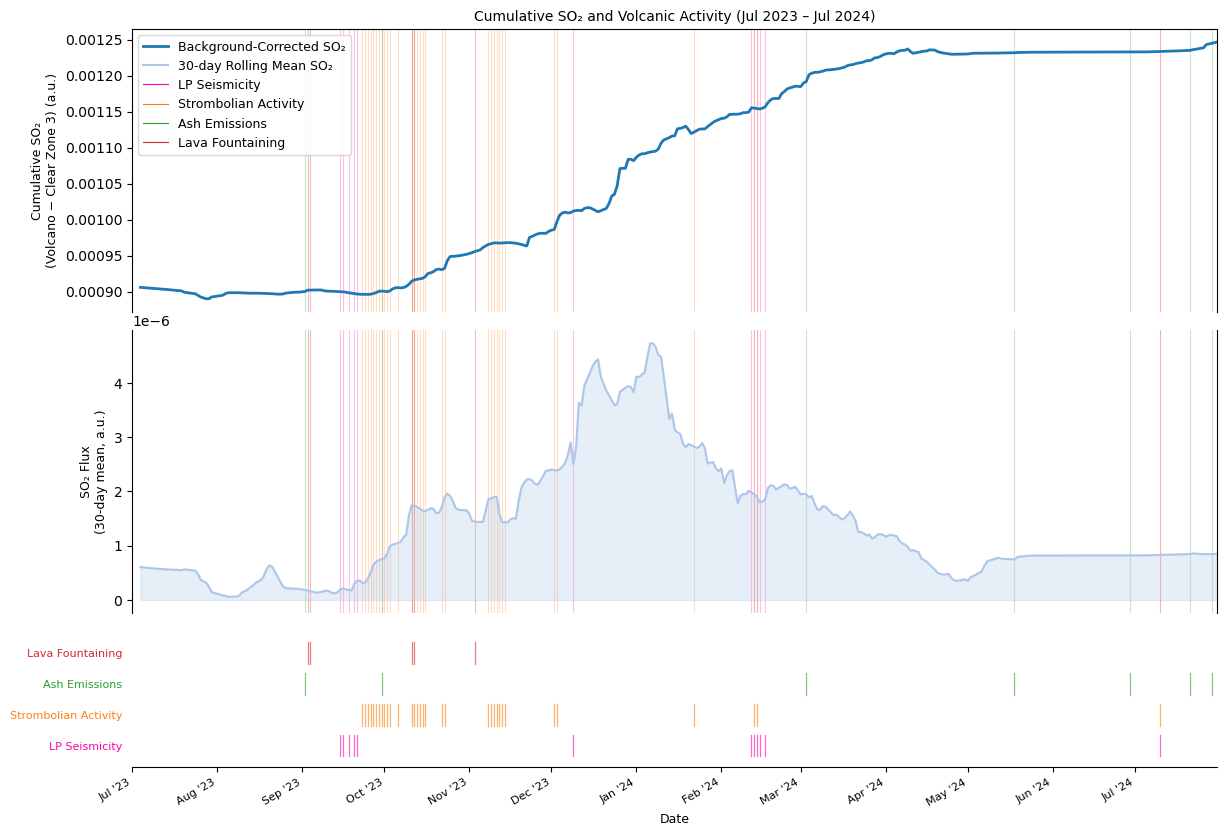

In [83]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['figure.dpi'] = 100

# --- Prepare data ---
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.replace(0, np.nan, inplace=True)
df.interpolate(inplace=True)

df['cumulative_volcano'] = df['volcano'].cumsum()
df['cumulative_clear_3'] = df['clear_3'].cumsum()
df['cumulative_true_volcano'] = df['cumulative_volcano'] - df['cumulative_clear_3']

# --- Rolling mean on full dataset before filtering ---
df['rolling_so2'] = df['volcano'].rolling(window=30, min_periods=5, center=True).mean()

# --- Filter to window ---
w_start = '2023-07-01'
w_end   = '2024-07-31'
df_w = df[(df['date'] >= w_start) & (df['date'] <= w_end)].copy()

# --- Filter event dates to window ---
strombolian_dt   = pd.to_datetime(strombolian_dates,   dayfirst=True)
lava_fountain_dt = pd.to_datetime(lava_fountain_dates, dayfirst=True)
lp_dt            = pd.to_datetime(lp_dates,            dayfirst=True)
ash_dt           = pd.to_datetime(ash_dates,           dayfirst=True)

def filter_dates(dates, start, end):
    return [d for d in dates if pd.Timestamp(start) <= d <= pd.Timestamp(end)]

lp_w    = filter_dates(lp_dt,            w_start, w_end)
strom_w = filter_dates(strombolian_dt,   w_start, w_end)
ash_w   = filter_dates(ash_dt,           w_start, w_end)
fnt_w   = filter_dates(lava_fountain_dt, w_start, w_end)

# --- Colours ---
SO2_col   = '#1f77b4'
ROLL_col  = '#aec7e8'
LP_col    = '#FF00AA'
STROM_col = '#ff7f0e'
ASH_col   = '#2ca02c'
FNT_col   = '#d62728'

event_types = [
    (lp_w,    1, LP_col,    'LP Seismicity'),
    (strom_w, 2, STROM_col, 'Strombolian Activity'),
    (ash_w,   3, ASH_col,   'Ash Emissions'),
    (fnt_w,   4, FNT_col,   'Lava Fountaining'),
]

# --- Figure layout: cumulative | rolling mean | activity ---
fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(3, 1,
                       height_ratios=[2.5, 2.5, 1.2],
                       hspace=0.08,
                       top=0.93)

ax_cum      = fig.add_subplot(gs[0])
ax_roll     = fig.add_subplot(gs[1])
ax_activity = fig.add_subplot(gs[2])

# ── Shared x limits ───────────────────────────────────────────────────────────
x_min = pd.Timestamp(w_start)
x_max = pd.Timestamp(w_end)

for ax in [ax_cum, ax_roll, ax_activity]:
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

# ── Cumulative SO₂ panel ──────────────────────────────────────────────────────
for date in lp_w:
    ax_cum.axvline(date, color=LP_col,    alpha=0.25, lw=0.8, zorder=1)
for date in strom_w:
    ax_cum.axvline(date, color=STROM_col, alpha=0.25, lw=0.8, zorder=1)
for date in ash_w:
    ax_cum.axvline(date, color=ASH_col,   alpha=0.25, lw=0.8, zorder=1)
for date in fnt_w:
    ax_cum.axvline(date, color=FNT_col,   alpha=0.30, lw=0.8, zorder=1)

ax_cum.plot(df_w['date'], df_w['cumulative_true_volcano'],
            lw=2, color=SO2_col, zorder=3)

ax_cum.set_ylabel('Cumulative SO₂\n(Volcano − Clear Zone 3) (a.u.)', fontsize=9)
ax_cum.set_title('Cumulative SO₂ and Volcanic Activity (Jul 2023 – Jul 2024)',
                 fontsize=10)
ax_cum.tick_params(labelbottom=False)
ax_cum.spines['bottom'].set_visible(False)
ax_cum.tick_params(axis='x', which='both', bottom=False)

legend_elements = [
    Line2D([0], [0], color=SO2_col,  lw=2,   label='Background-Corrected SO₂'),
    Line2D([0], [0], color=ROLL_col, lw=1.5, label='30-day Rolling Mean SO₂'),
    Line2D([0], [0], color=LP_col,    lw=0.8, label='LP Seismicity'),
    Line2D([0], [0], color=STROM_col, lw=0.8, label='Strombolian Activity'),
    Line2D([0], [0], color=ASH_col,   lw=0.8, label='Ash Emissions'),
    Line2D([0], [0], color=FNT_col,   lw=0.8, label='Lava Fountaining'),
]
ax_cum.legend(handles=legend_elements, loc='upper left', fontsize=9,
              framealpha=0.9, edgecolor='lightgrey')

# ── Rolling mean panel ────────────────────────────────────────────────────────
for date in lp_w:
    ax_roll.axvline(date, color=LP_col,    alpha=0.25, lw=0.8, zorder=1)
for date in strom_w:
    ax_roll.axvline(date, color=STROM_col, alpha=0.25, lw=0.8, zorder=1)
for date in ash_w:
    ax_roll.axvline(date, color=ASH_col,   alpha=0.25, lw=0.8, zorder=1)
for date in fnt_w:
    ax_roll.axvline(date, color=FNT_col,   alpha=0.30, lw=0.8, zorder=1)

ax_roll.plot(df_w['date'], df_w['rolling_so2'],
             lw=1.5, color=ROLL_col, zorder=3)
ax_roll.fill_between(df_w['date'], df_w['rolling_so2'],
                     alpha=0.3, color=ROLL_col, zorder=2)

ax_roll.set_ylabel('SO₂ Flux\n(30-day mean, a.u.)', fontsize=9)
ax_roll.tick_params(labelbottom=False)
ax_roll.spines['bottom'].set_visible(False)
ax_roll.spines['top'].set_visible(False)
ax_roll.tick_params(axis='x', which='both', bottom=False)

# ── Activity panel ────────────────────────────────────────────────────────────
y_labels = {}
for dates, y_pos, colour, label in event_types:
    for date in dates:
        ax_activity.plot([date, date], [y_pos - 0.35, y_pos + 0.35],
                         color=colour, lw=0.9, alpha=0.6)
    y_labels[y_pos] = (label, colour)

ax_activity.set_yticks(sorted(y_labels.keys()))
ax_activity.set_yticklabels(
    [y_labels[k][0] for k in sorted(y_labels.keys())], fontsize=8)
for tick_label, k in zip(ax_activity.get_yticklabels(), sorted(y_labels.keys())):
    tick_label.set_color(y_labels[k][1])

ax_activity.set_ylim(0.3, 4.7)
ax_activity.set_xlabel('Date', fontsize=9)
plt.setp(ax_activity.get_xticklabels(), rotation=30, ha='right', fontsize=8)
for spine in ['top', 'right', 'left']:
    ax_activity.spines[spine].set_visible(False)
ax_activity.tick_params(left=False)

plt.savefig("zoomed_2023_2024_rolling.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\davie\AppData\Local\Temp\ipykernel_21440\4185442746.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


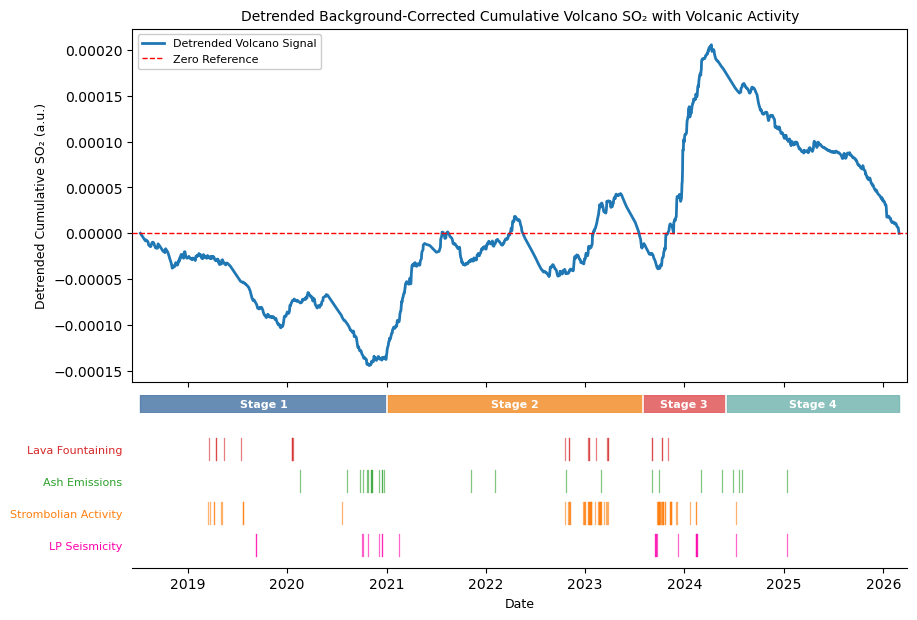

In [87]:
import datetime as dt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Convert dates to matplotlib numeric format ---
dates_num = mdates.date2num(df['date'])

# --- Linear trend from start to end ---
start_val = df['cumulative_true_volcano'].iloc[0]
end_val   = df['cumulative_true_volcano'].iloc[-1]

linear_trend = start_val + (end_val - start_val) * (
    (dates_num - dates_num[0]) / (dates_num[-1] - dates_num[0])
)

df['detrended_true_volcano'] = df['cumulative_true_volcano'] - linear_trend

# --- Event definitions ---
event_types = [
    (lp_dt,            1, LP_col,    'LP Seismicity'),
    (strombolian_dt,   2, STROM_col, 'Strombolian Activity'),
    (ash_dt,           3, ASH_col,   'Ash Emissions'),
    (lava_fountain_dt, 4, FNT_col,   'Lava Fountaining'),
]

# --- Stage definitions ---
stages = [
    (df['date'].min(),          pd.Timestamp('2021-01-01'), 'Stage 1', '#4e79a7'),
    (pd.Timestamp('2021-01-01'), pd.Timestamp('2023-08-01'), 'Stage 2', '#f28e2b'),
    (pd.Timestamp('2023-08-01'), pd.Timestamp('2024-06-01'), 'Stage 3', '#e15759'),
    (pd.Timestamp('2024-06-01'), df['date'].max(),           'Stage 4', '#76b7b2'),
]

# --- Figure layout: detrended | stage bar | activity ---
fig = plt.figure(figsize=(10, 7))
gs  = fig.add_gridspec(3, 1,
                       height_ratios=[3, 0.15, 1.2],
                       hspace=0.08)

ax_det      = fig.add_subplot(gs[0])
ax_stage    = fig.add_subplot(gs[1])
ax_activity = fig.add_subplot(gs[2])

# ── Shared x limits ───────────────────────────────────────────────────────────
x_min = df['date'].min() - pd.Timedelta(days=30)
x_max = df['date'].max() + pd.Timedelta(days=30)

for ax in [ax_det, ax_stage, ax_activity]:
    ax.set_xlim(x_min, x_max)

ax_det.xaxis.set_major_locator(mdates.AutoDateLocator())
ax_det.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
ax_activity.xaxis.set_major_locator(mdates.AutoDateLocator())
ax_activity.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

# ── Detrended SO₂ panel ───────────────────────────────────────────────────────
ax_det.plot(df['date'], df['detrended_true_volcano'],
            lw=2, color=SO2_col, label='Detrended Volcano Signal', zorder=3)
ax_det.axhline(0, color='r', linestyle='--', lw=1, zorder=3, label='Zero Reference')

ax_det.set_ylabel('Detrended Cumulative SO₂ (a.u.)', fontsize=9)
ax_det.set_title(
    'Detrended Background-Corrected Cumulative Volcano SO₂ with Volcanic Activity',
    fontsize=10)
ax_det.tick_params(labelbottom=False)
ax_det.legend(loc='best', fontsize=8, framealpha=1)

# ── Stage bar ─────────────────────────────────────────────────────────────────
from matplotlib.transforms import blended_transform_factory

for start, end, label, colour in stages:
    # Filled block spanning full height of the stage axes
    ax_stage.axvspan(start, end, color=colour, alpha=0.85)
    # Centred label
    mid = start + (end - start) / 2
    ax_stage.text(mid, 0.5, label,
                  transform=blended_transform_factory(ax_stage.transData,
                                                      ax_stage.transAxes),
                  ha='center', va='center', fontsize=8,
                  fontweight='bold', color='white')

# Add boundary lines between stages
for _, end, _, _ in stages[:-1]:
    ax_stage.axvline(end, color='white', lw=1.2, zorder=5)

ax_stage.set_yticks([])
ax_stage.set_xticks([])
for spine in ax_stage.spines.values():
    spine.set_visible(False)

# ── Activity panel ────────────────────────────────────────────────────────────
y_labels = {}
for dates, y_pos, colour, label in event_types:
    for date in dates:
        ax_activity.plot([date, date], [y_pos - 0.35, y_pos + 0.35],
                         color=colour, lw=0.9, alpha=0.6)
    y_labels[y_pos] = (label, colour)

ax_activity.set_yticks(sorted(y_labels.keys()))
ax_activity.set_yticklabels(
    [y_labels[k][0] for k in sorted(y_labels.keys())], fontsize=8)
for tick_label, k in zip(ax_activity.get_yticklabels(), sorted(y_labels.keys())):
    tick_label.set_color(y_labels[k][1])

ax_activity.set_ylim(0.3, 4.7)
ax_activity.set_xlabel('Date', fontsize=9)
for spine in ['top', 'right', 'left']:
    ax_activity.spines[spine].set_visible(False)
ax_activity.tick_params(left=False)

plt.tight_layout()
plt.savefig("figuredetrended3.png", dpi=500, bbox_inches='tight')
plt.show()